In [199]:
!pip install --upgrade pip

!pip install xgboost
!pip install lightgbm
!pip install shap --upgrade -q

import shap
shap.initjs()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [200]:
!pip install kneed

In [111]:
%matplotlib inline
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (6, 4) },
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, \
TargetEncoder, MinMaxScaler, OrdinalEncoder, FunctionTransformer, \
PolynomialFeatures, PowerTransformer, QuantileTransformer

from sklearn.compose import TransformedTargetRegressor

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression, RFECV, mutual_info_regression, mutual_info_classif

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, \
 mean_absolute_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, \
AdaBoostClassifier, \
BaggingClassifier, \
ExtraTreesClassifier, \
GradientBoostingClassifier, \
HistGradientBoostingClassifier, \
StackingClassifier, \
VotingClassifier, \
IsolationForest

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import RandomOverSampler

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import cross_val_score, GridSearchCV, ParameterGrid, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
df = pd.read_csv('https://media.geeksforgeeks.org/wp-content/uploads/20240510131249/Rainfall.csv')

In [9]:
df.head(5)

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [3]:
df.shape

(366, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [6]:
df.isna().sum()

,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0


In [4]:
df.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [7]:
df.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [8]:
df.rename(str.strip, axis='columns', inplace=True)
df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

# EDA

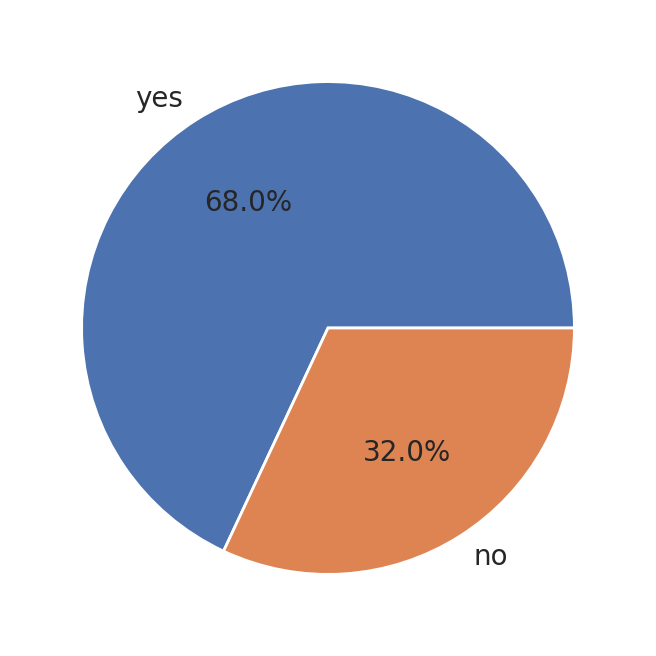

In [11]:
plt.pie(df['rainfall'].value_counts().values,
        labels = df['rainfall'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

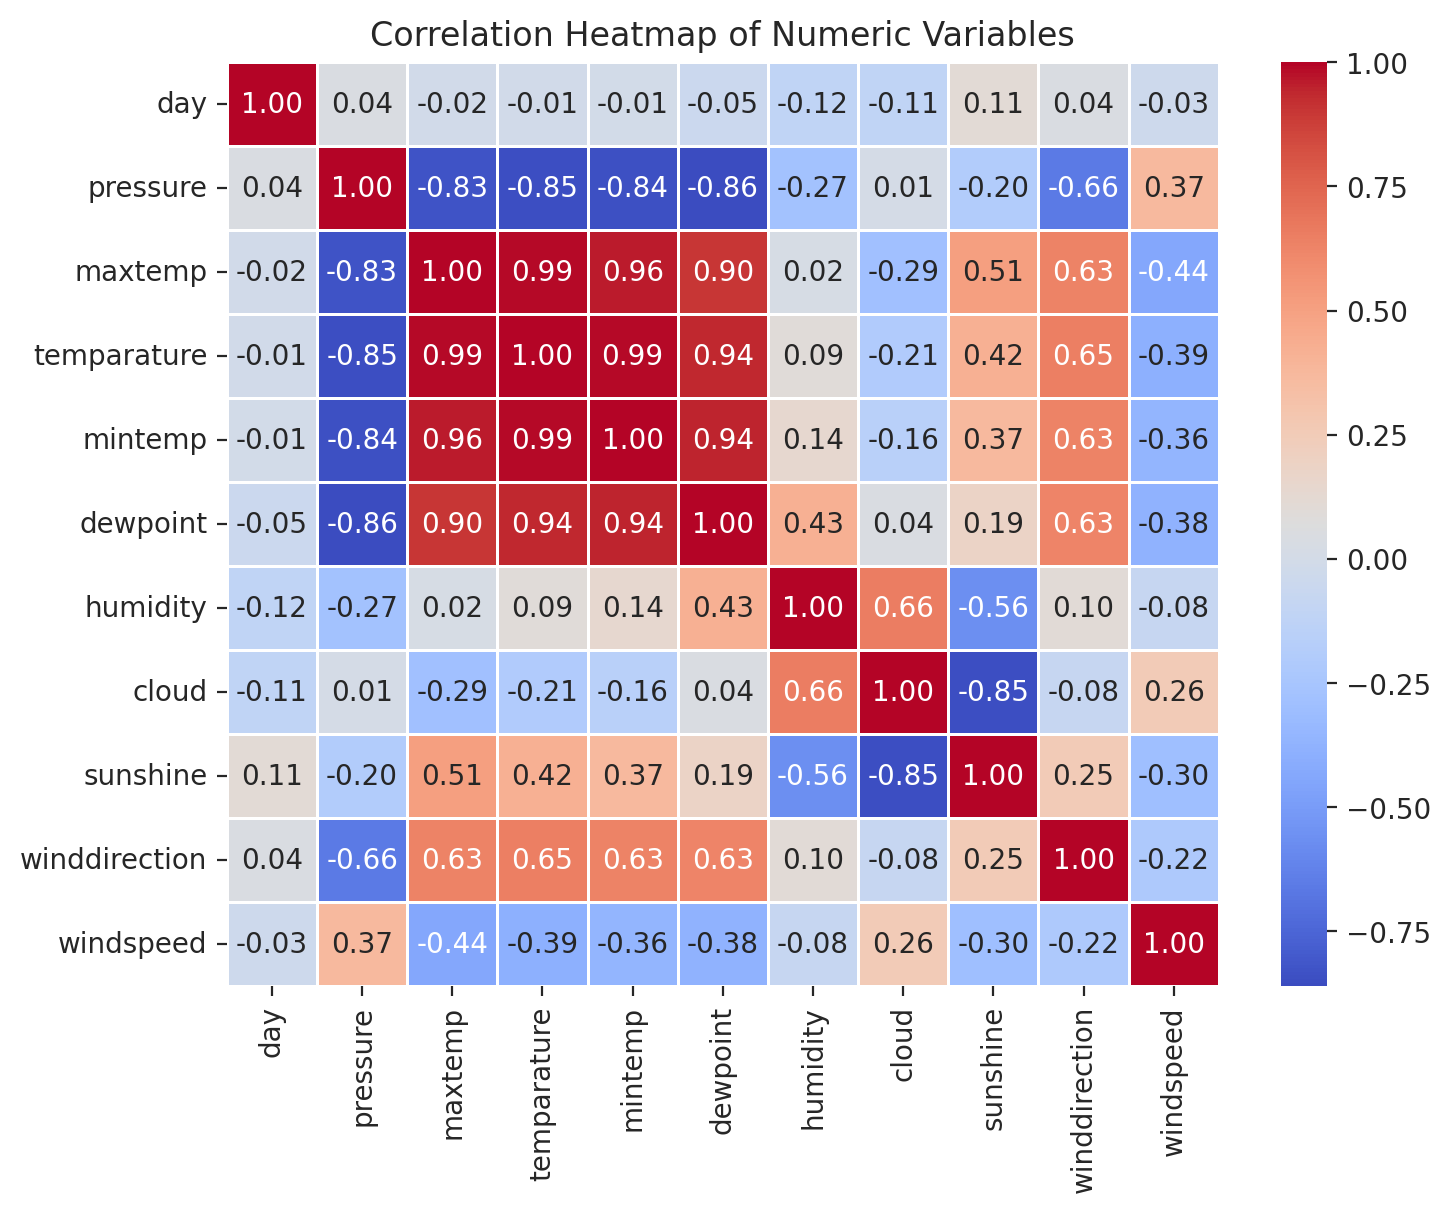

In [10]:
features = list(df.select_dtypes(include = np.number).columns)

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


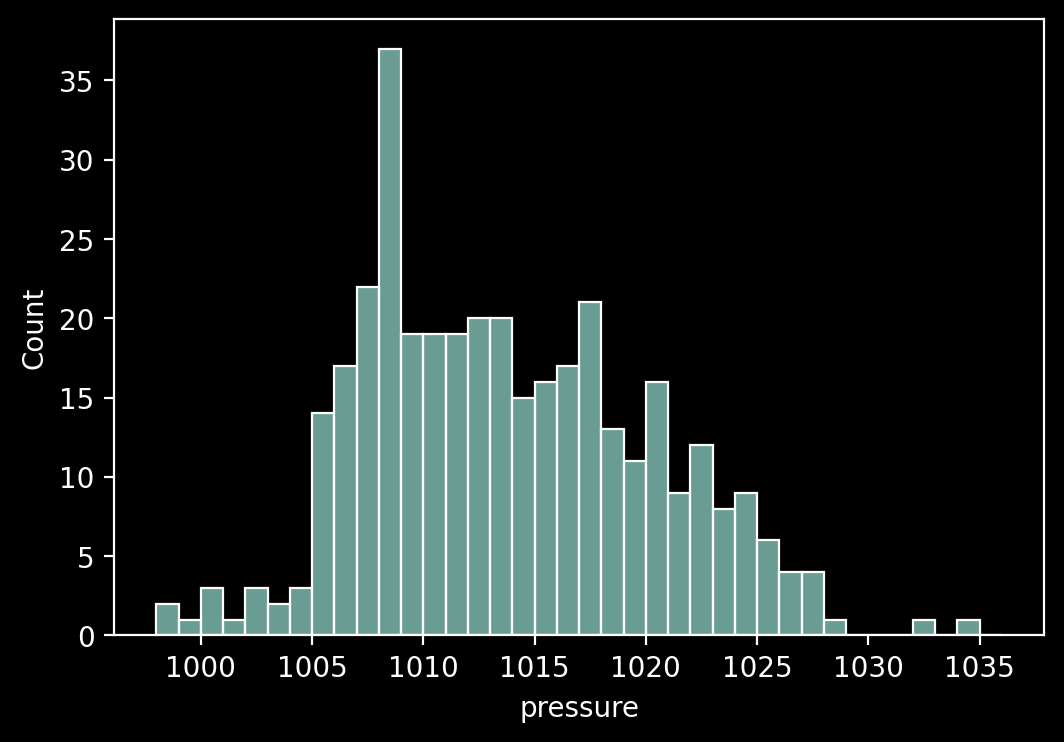

In [183]:
sns.histplot(df.pressure, discrete=True);

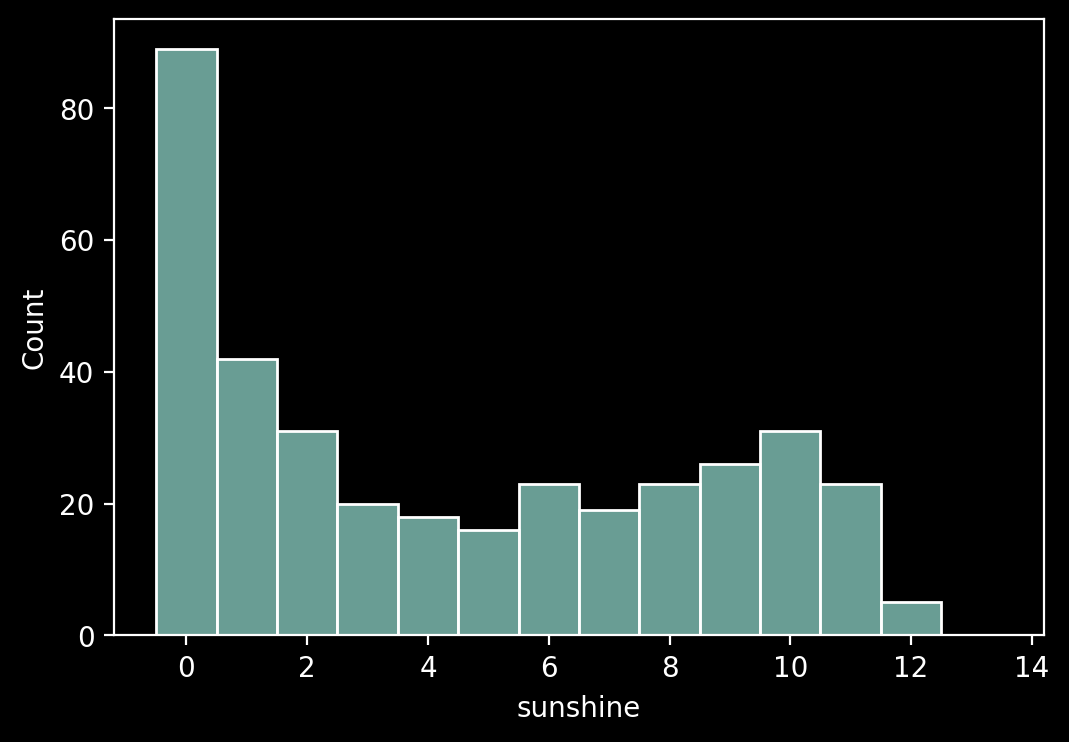

In [184]:
sns.histplot(df.sunshine, discrete=True);

['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed']


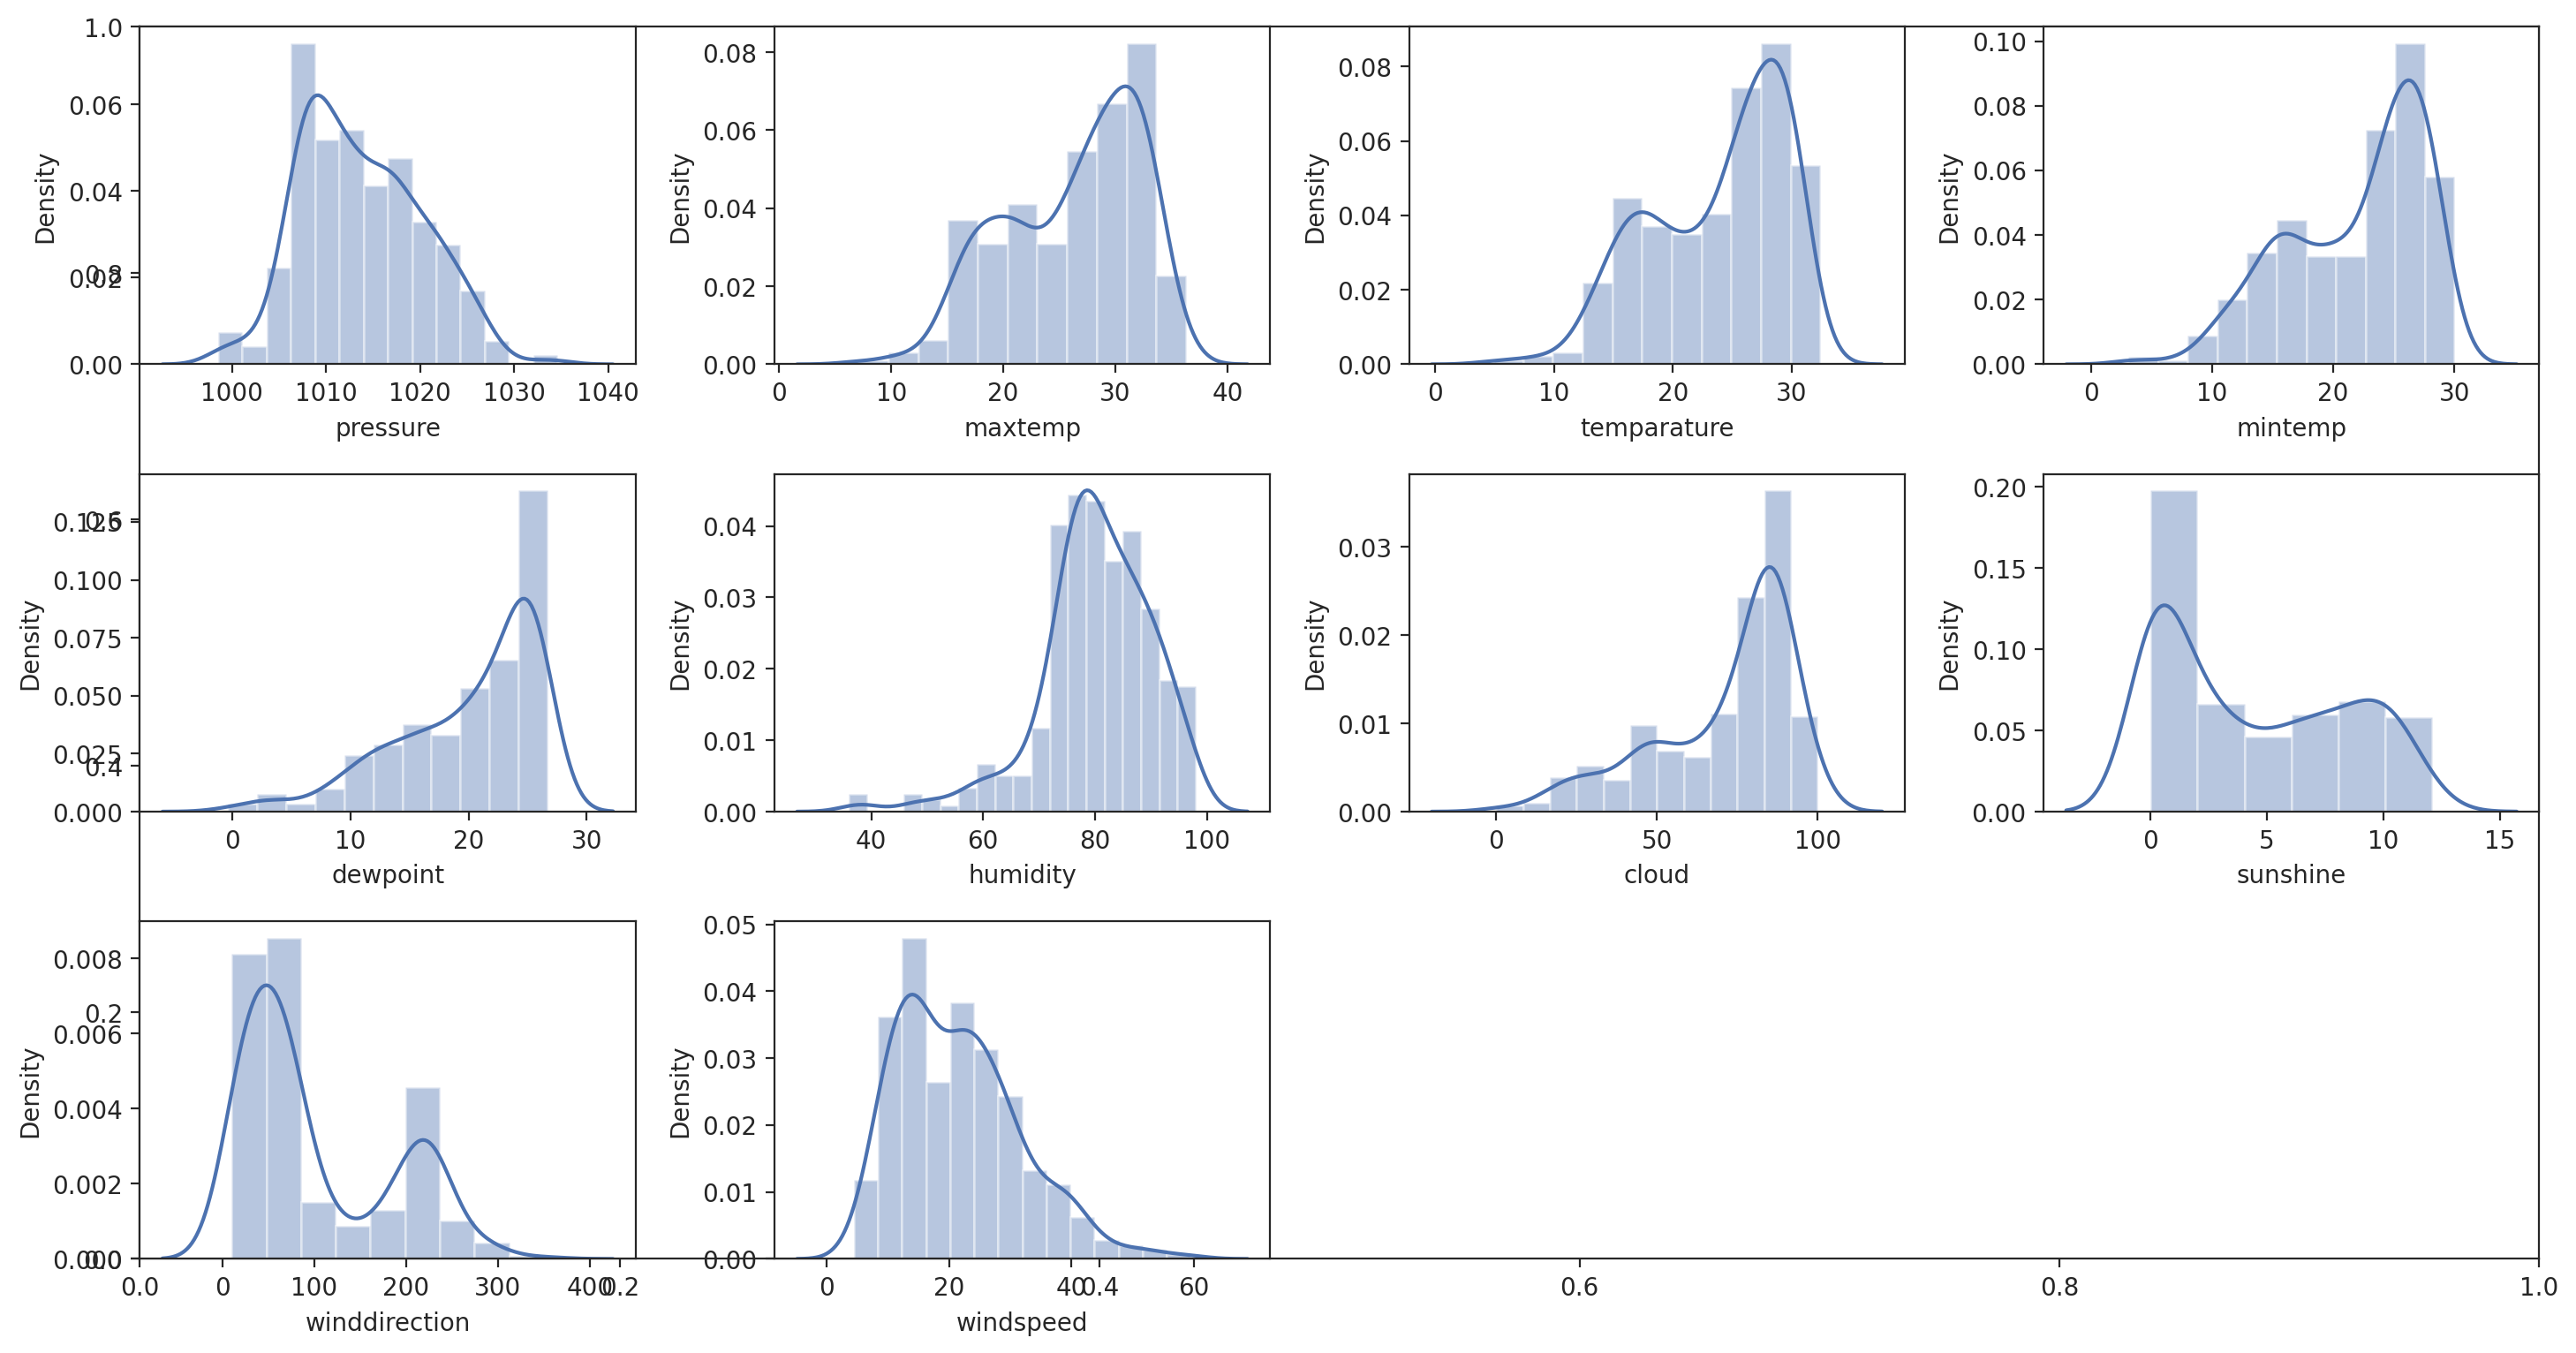

In [17]:

print(features)

plt.subplots(figsize=(15,8))

for i, col in enumerate(features):
  plt.subplot(3,4, i + 1)
  sns.distplot(df[col])
plt.tight_layout()
plt.show()

In [18]:
df.drop(['maxtemp', 'mintemp'], axis=1, inplace=True)

# Data

In [23]:
target = 'rainfall'
target_col = df.rainfall

In [52]:
X = df.drop(['day', target], axis=1)
y = df.rainfall

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                      y,
                                      test_size=0.2,
                                      stratify=target_col,
                                      random_state=2)


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_tr = y_train
y_tes  = y_test

y_train = LabelEncoder().fit_transform(y_train)
y_test = LabelEncoder().fit_transform(y_test)

## Pipeline

In [76]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

numeric_features = ['pressure', 'temparature', 'dewpoint', 'humidity', 'cloud',	'sunshine', 'winddirection', 'windspeed']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    verbose_feature_names_out=False
)


## Automatic Feature Selection

In [77]:
# Using Random Forest Regressor (score with 'r2' or 'neg_mean_squared_error')
rf_selector_RFECV = RFECV(
    estimator=RandomForestClassifier(random_state=42),
    step=1,
    cv=3,
    scoring='balanced_accuracy',
    min_features_to_select=1,
    n_jobs=-1
)

# Pipeline Steps
steps = [
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
    ("featsel",      rf_selector_RFECV),
]

rf_fs_RFECV = ImbPipeline(steps)
rf_fs_RFECV.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pressure', 'temparature',
                                                   'dewpoint', 'humidity',
                                                   'cloud', 'sunshine',
                                                   'winddirection',
                                                   'windspeed'])],
                                   verbose_feature_names_out=False)),
                ('sampler',
                 RandomOverSampler(random_state=22,
                                   sampling_strategy='minority')),
                ('featsel',
                 RFECV(cv=3, estimator=RandomForestClassifier(random_state=42),
                       n_jobs=-1, scoring='balanced_accuracy'))])

In [78]:
# Results
rf_recv = rfecv = rf_fs_RFECV.named_steps['featsel']
preprocessor = rf_fs_RFECV.named_steps['preprocessor']

feature_names     = preprocessor.get_feature_names_out()
mask              = rfecv.support_
selected_features = feature_names[mask]

print(f"\n Optimal number of features: {rfecv.n_features_}\n")
print(f"Selected features:\n{selected_features}\n")

# Results DataFrame
rf_recv_df = rfecv_df = pd.DataFrame({
    "feature": feature_names,
    "selected": rfecv.support_,
    "ranking":  rfecv.ranking_,
    "model": ['RandomForestClassifier' for _ in feature_names]
})

selected_df = rfecv_df[rfecv_df["selected"]].sort_values("ranking")
print(selected_df.to_string(index=False))

# Feature Importances on Selected Features
X_transformed = preprocessor.transform(X_train)
X_selected    = X_transformed[:, rfecv.support_]

final_model = RandomForestClassifier(random_state=42)
final_model.fit(X_selected, y_train)

rf_importance_df = importance_df = pd.DataFrame({
    "feature":    selected_features,
    "importance": final_model.feature_importances_,
    "ranking":    rfecv.ranking_[mask],
    "model": ['RandomForestClassifier' for _ in selected_features]
}).sort_values("importance", ascending=False)

print(importance_df.to_string(index=False))


 Optimal number of features: 8

Selected features:
['pressure' 'temparature' 'dewpoint' 'humidity' 'cloud' 'sunshine'
 'winddirection' 'windspeed']

      feature  selected  ranking                  model
     pressure      True        1 RandomForestClassifier
  temparature      True        1 RandomForestClassifier
     dewpoint      True        1 RandomForestClassifier
     humidity      True        1 RandomForestClassifier
        cloud      True        1 RandomForestClassifier
     sunshine      True        1 RandomForestClassifier
winddirection      True        1 RandomForestClassifier
    windspeed      True        1 RandomForestClassifier
      feature  importance  ranking                  model
        cloud    0.239412        1 RandomForestClassifier
     sunshine    0.213352        1 RandomForestClassifier
     humidity    0.132812        1 RandomForestClassifier
    windspeed    0.099182        1 RandomForestClassifier
     pressure    0.093351        1 RandomForestClassifie

In [79]:
BG     = '#0d1117'
SURF   = '#161b22'
CYAN   = '#39d0f5'
PURPLE = '#a371f7'
AMBER  = '#f0b429'
CORAL  = '#ff6b6b'
GREEN  = '#3fb950'
MUTED  = '#7d8590'
GRID_COLOR = '#ff5733'

# Graph 1: CV Score vs Number of Features
def plot_features_vs_cvscore(rfecv_model):
    plt.style.use('dark_background')

    scores    = rfecv_model.cv_results_['mean_test_score']
    stds      = rfecv_model.cv_results_['std_test_score']
    n_range   = range(1, len(scores) + 1)
    best_n    = rfecv_model.n_features_

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(SURF)

    # Shaded std band
    ax.fill_between(n_range,
                    scores - stds,
                    scores + stds,
                    alpha=0.25, color=CYAN, label='+/- 1 std dev')

    # Main score line
    ax.plot(n_range, scores, color=CYAN, lw=2.5, zorder=3, label='Mean R2 (CV=3)')

    # Best point
    best_score = scores[best_n - 1]
    ax.axvline(best_n, color=AMBER, lw=1.5, linestyle='--', alpha=0.8)
    ax.scatter([best_n], [best_score], color=AMBER, s=100, zorder=5,
               label=f'Optimal: {best_n} features (R²={best_score:.4f})')
    ax.annotate(f'  n={best_n}\n  R²={best_score:.4f}',
                xy=(best_n, best_score),
                xytext=(best_n + max(1, len(scores)*0.03), best_score - 0.02),
                color=AMBER, fontsize=10)

    ax.set_title('Random Forest: RFECV — CV R2 Score vs Number of Features Selected',
                 color='#e6edf3', fontsize=14, pad=14)
    ax.set_xlabel('Number of Features Selected', color=MUTED, fontsize=11)
    ax.set_ylabel('Mean CV R2 Score', color=MUTED, fontsize=11)
    ax.tick_params(colors=MUTED)
    ax.grid(color='#ff5733', linestyle='--', linewidth=0.6)
    ax.legend(facecolor=SURF, edgecolor=MUTED, labelcolor='#e6edf3', fontsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

    plt.tight_layout()
    plt.show()

# Graph 2: Feature Importances (selected features)
def plot_feature_importances(imp_df, top_n=20):
    plt.style.use('dark_background')
    df = imp_df.head(top_n).sort_values('importance')

    fig, ax = plt.subplots(figsize=(12, max(5, len(df) * 0.38)))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(SURF)

    cmap   = plt.cm.plasma
    colors = [cmap(v) for v in np.linspace(0.25, 0.85, len(df))]

    bars = ax.barh(df['feature'], df['importance'],
                   color=colors, edgecolor=BG, linewidth=0.4, height=0.7)

    for bar, val in zip(bars, df['importance']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', color='#e6edf3', fontsize=9)

    ax.set_title('Random Forest Feature Importances (RFECV Selected Features)',
                 color='#e6edf3', fontsize=13, pad=12)
    ax.set_xlabel('Importance Score', color=MUTED, fontsize=11)
    ax.tick_params(colors=MUTED)
    ax.grid(axis='x', color='#ff5733', linestyle='--', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

    plt.tight_layout()
    plt.show()

# plot_feature_importances(importance_df)


# Graph 3: Feature Ranking (all features, eliminated vs selected)
def plot_feature_ranking(rfecv_df_full):
    plt.style.use('dark_background')
    df = rfecv_df_full.sort_values('ranking')

    fig, ax = plt.subplots(figsize=(12, max(6, len(df) * 0.35)))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(SURF)

    colors = [GREEN if s else CORAL for s in df['selected']]
    bars   = ax.barh(df['feature'], df['ranking'],
                     color=[c + 'cc' for c in colors],
                     edgecolor=colors, linewidth=0.8, height=0.7)

    ax.axvline(1, color=AMBER, lw=1.2, linestyle='--', alpha=0.7, label='Rank 1 = Selected')
    ax.set_title('Random Forest: RFECV Feature Ranking — Selected vs Eliminated',
                 color='#e6edf3', fontsize=13, pad=12)
    ax.set_xlabel('Ranking (1 = best / selected)', color=MUTED, fontsize=11)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(axis='x', color='#ff5733', linestyle='--', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor=GREEN+'cc', edgecolor=GREEN, label='Selected'),
                  Patch(facecolor=CORAL+'cc', edgecolor=CORAL, label='Eliminated')]
    ax.legend(handles=legend_els, facecolor=SURF, edgecolor=MUTED,
              labelcolor='#e6edf3', fontsize=10)

    plt.tight_layout()
    plt.show()

# plot_feature_ranking(rfecv_df)

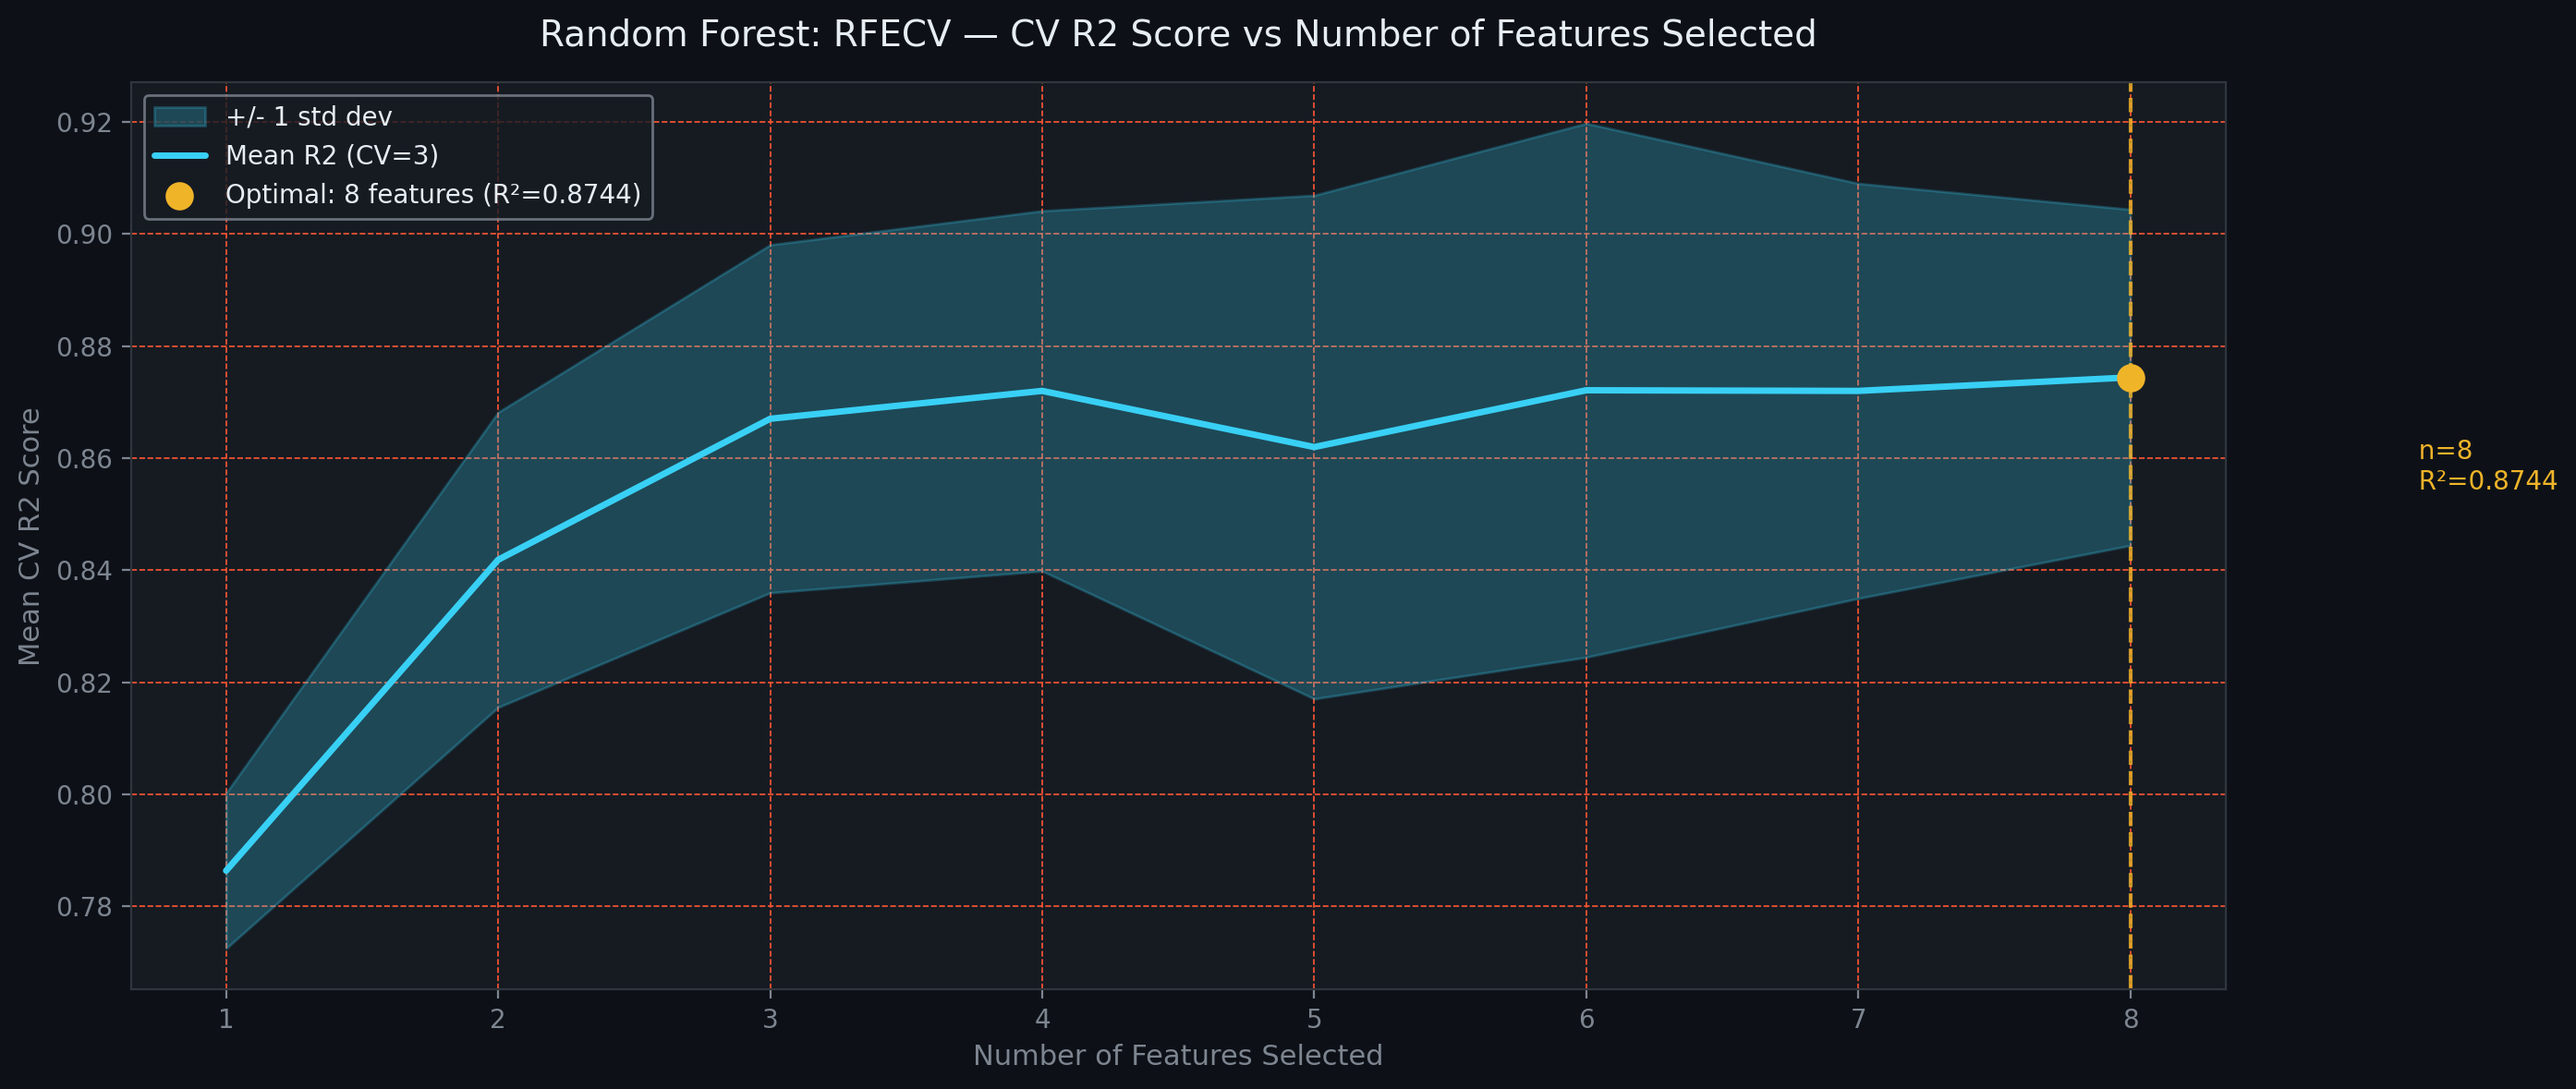

In [80]:
plot_features_vs_cvscore(rfecv)

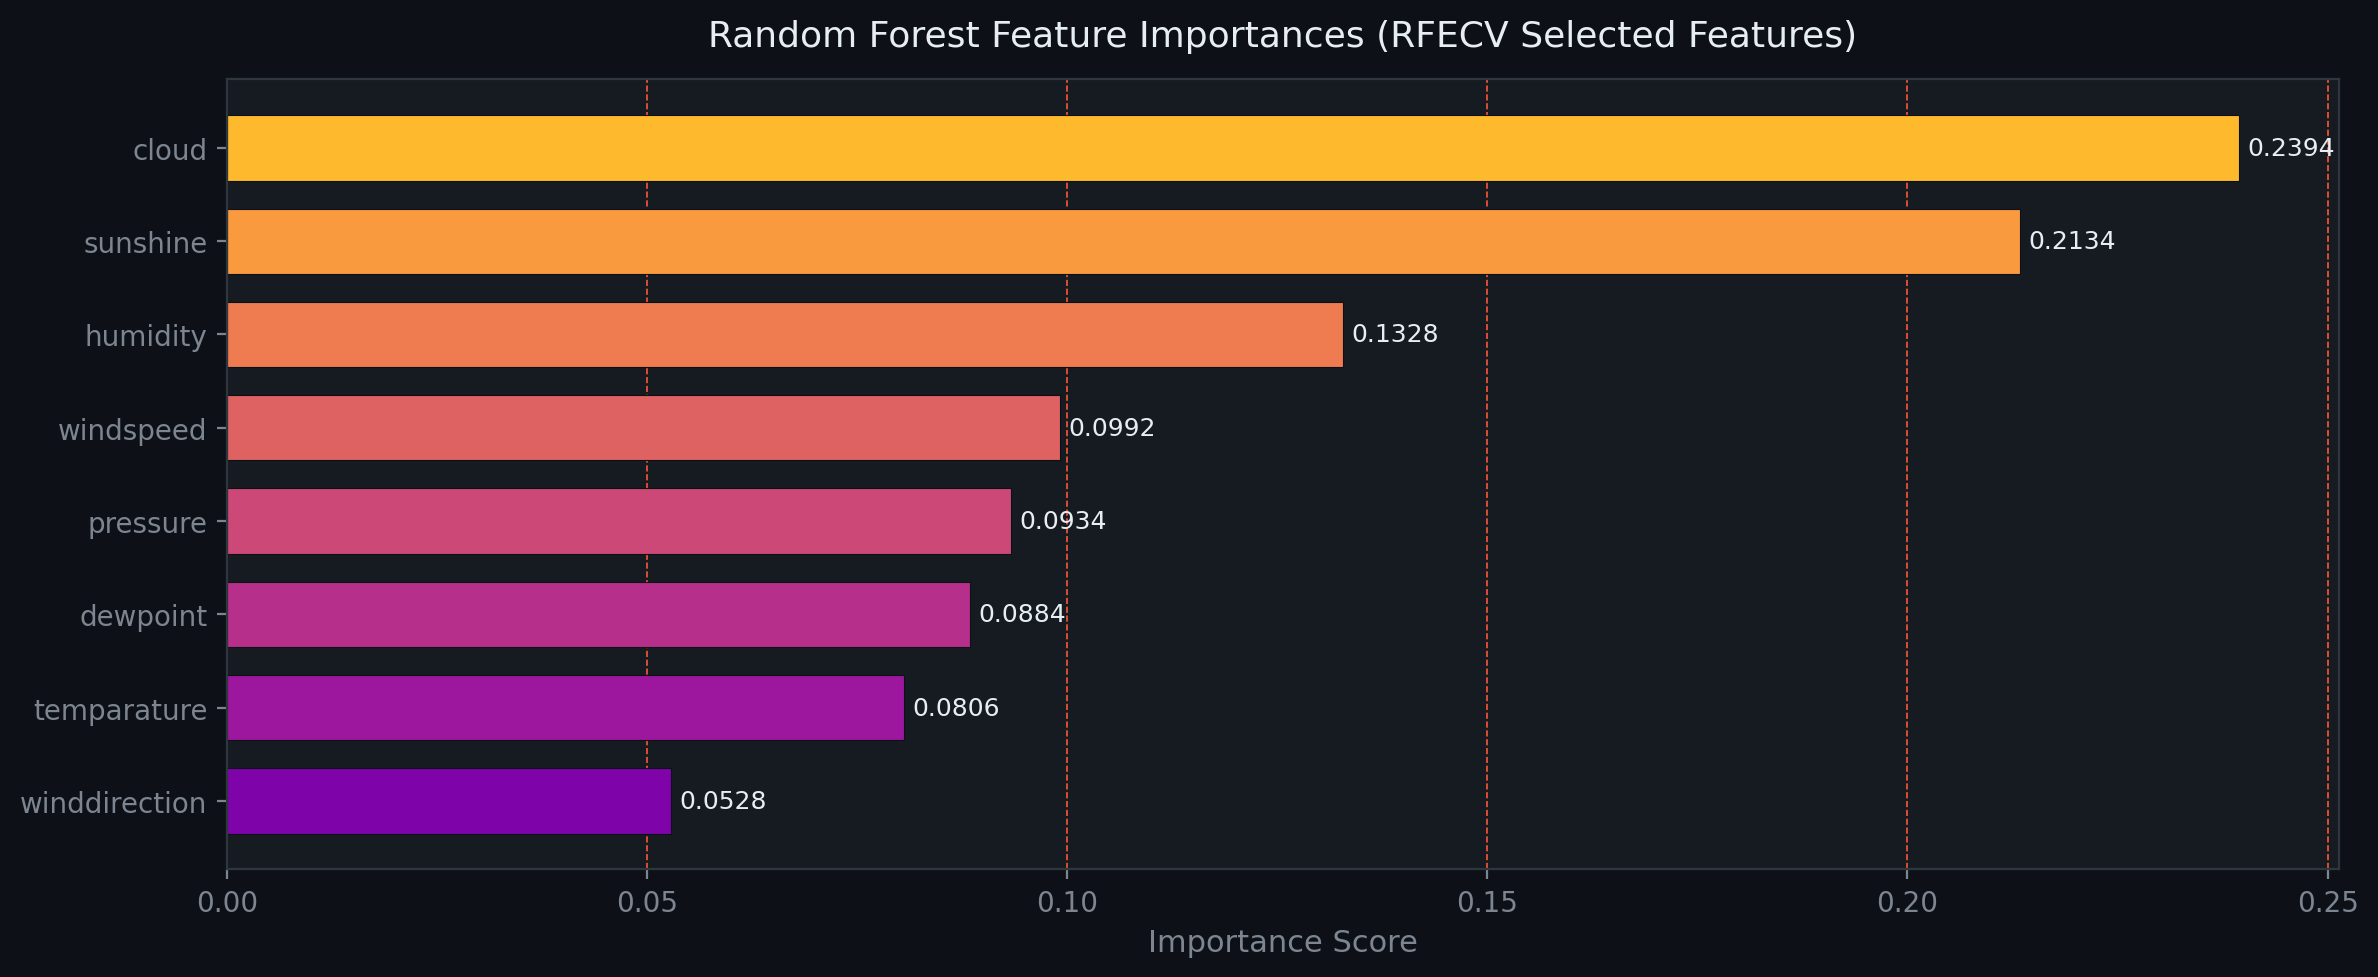

In [81]:
plot_feature_importances(importance_df)

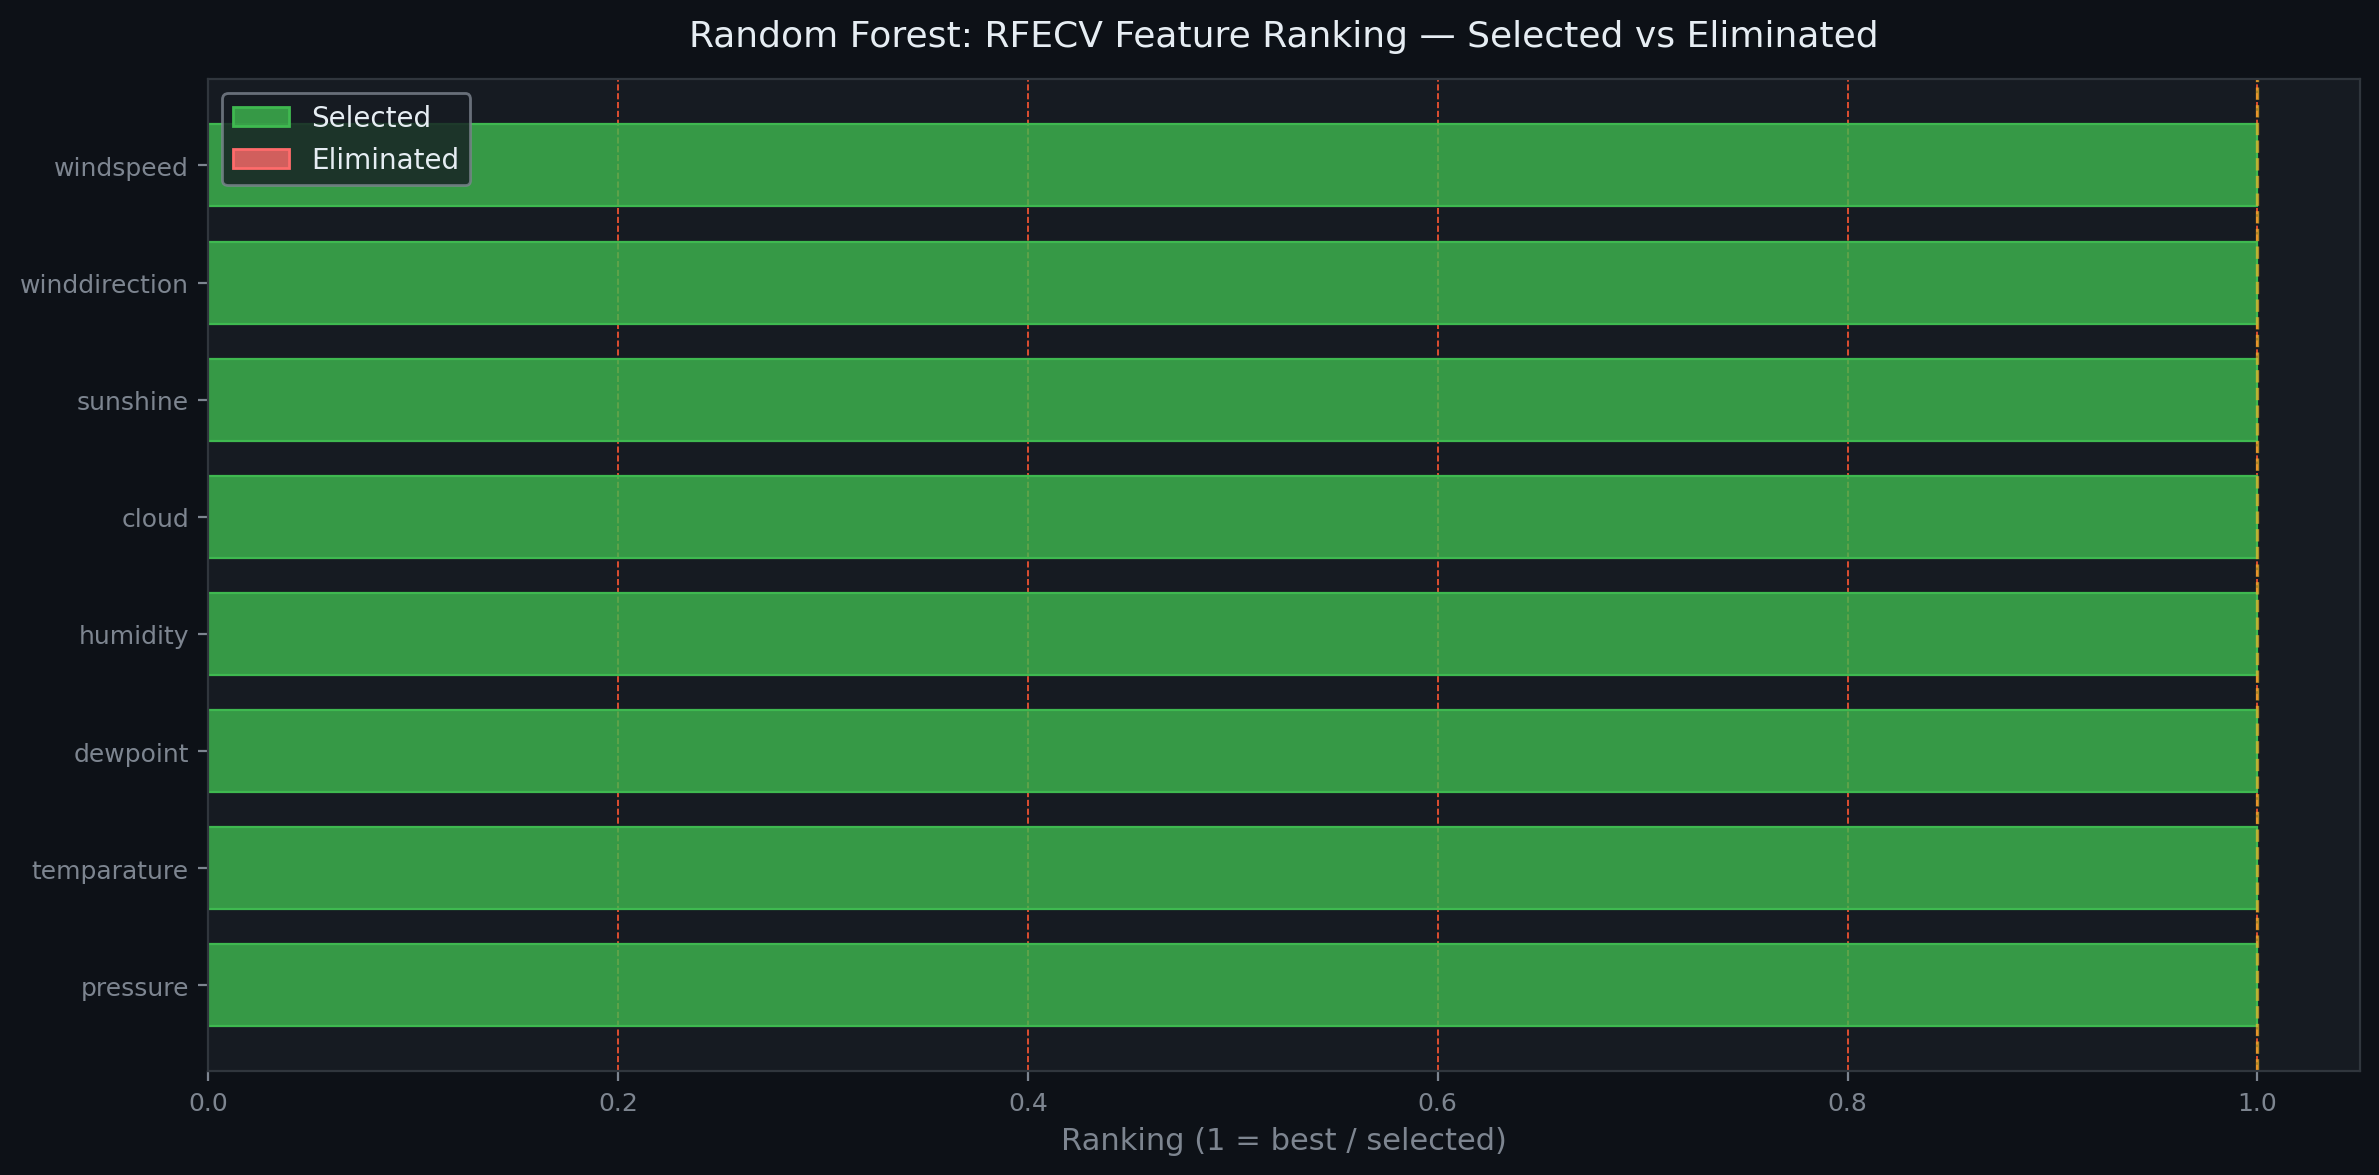

In [82]:
plot_feature_ranking(rfecv_df)

### Select K-Best

In [83]:
# Initialize SelectKBest with the chi-squared test
k_best_selector = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('featsel', SelectKBest(score_func=mutual_info_classif, k=10))
])

# Fit and transform the data
X_new = k_best_selector.fit_transform(X_train, y_train)

# Selected features
selected_features = k_best_selector.named_steps['featsel'].get_support(indices=True)
# Get feature names after preprocessing
feature_names = k_best_selector.named_steps['preprocessor'].get_feature_names_out()

# Map selected indices to names
selected_feature_names = feature_names[selected_features]

print(selected_feature_names)

['pressure' 'temparature' 'dewpoint' 'humidity' 'cloud' 'sunshine'
 'winddirection' 'windspeed']


In [84]:
# Access steps
selector = k_best_selector.named_steps['featsel']
preprocessor = k_best_selector.named_steps['preprocessor']

# Get feature names and scores
feature_names = preprocessor.get_feature_names_out()
feature_scores = selector.scores_

# Build DataFrame
feature_scores_df = pd.DataFrame({
    'feature': feature_names,
    'score': feature_scores
})

# Sort by score (descending)
feature_scores_df = feature_scores_df.sort_values(by='score', ascending=False)

print(feature_scores_df)

         feature     score
5       sunshine  0.197830
4          cloud  0.194146
3       humidity  0.106712
7      windspeed  0.050584
0       pressure  0.022888
1    temparature  0.021520
2       dewpoint  0.000000
6  winddirection  0.000000


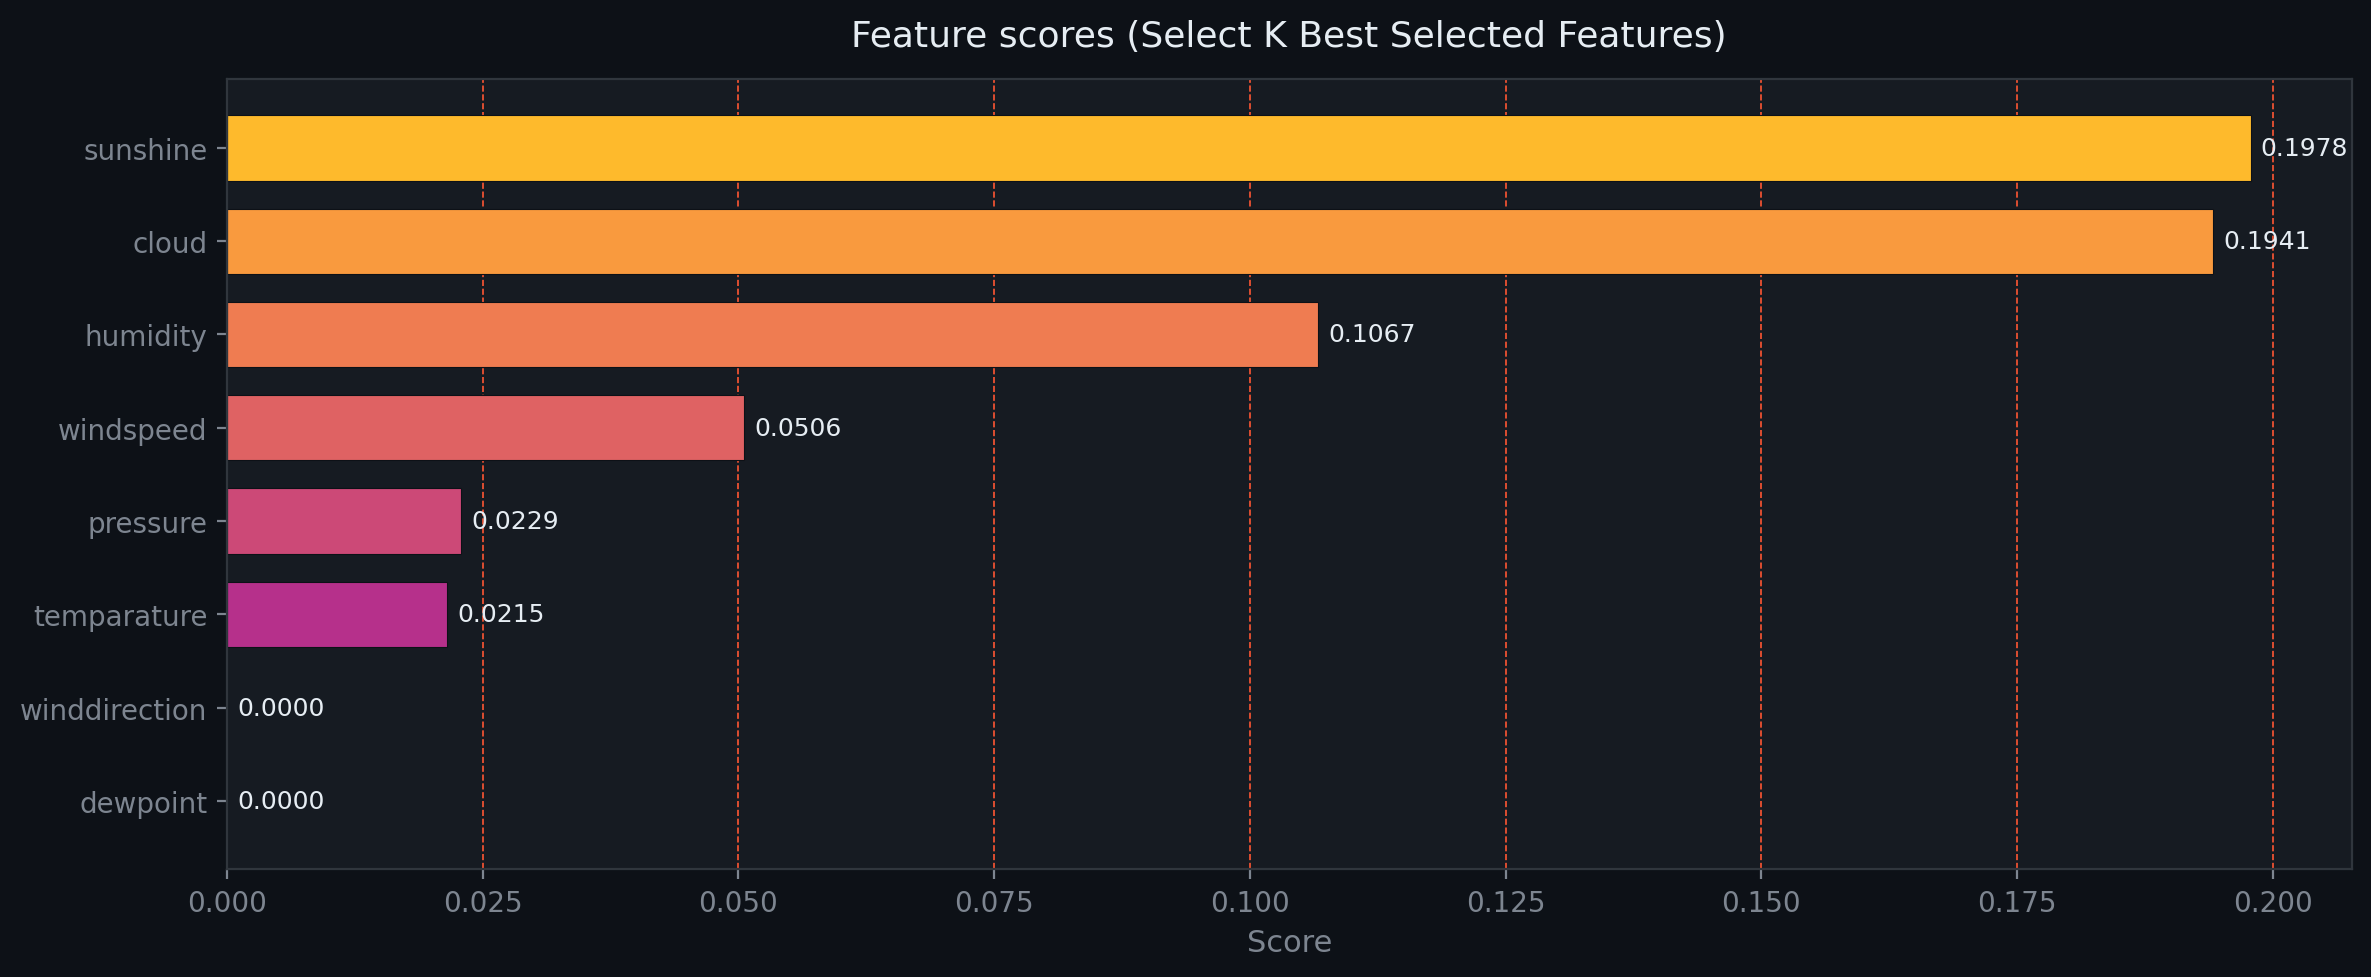

In [85]:
"""
plt.figure(figsize=(12,6))
fsdf = feature_scores_df.sort_values(by='score', ascending=True)
plt.barh(fsdf['feature'], fsdf['score'])
plt.title("Feature Select K-BEst")
plt.xlabel("Val")
plt.show()
"""


BG     = '#0d1117'
SURF   = '#161b22'
CYAN   = '#39d0f5'
PURPLE = '#a371f7'
AMBER  = '#f0b429'
CORAL  = '#ff6b6b'
GREEN  = '#3fb950'
MUTED  = '#7d8590'

def plot_feature_scores(fs_df, top_n=20):
    plt.style.use('dark_background')
    df = fs_df.head(top_n).sort_values('score')

    fig, ax = plt.subplots(figsize=(12, max(5, len(df) * 0.38)))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(SURF)

    cmap   = plt.cm.plasma
    colors = [cmap(v) for v in np.linspace(0.25, 0.85, len(df))]

    bars = ax.barh(df['feature'], df['score'],
                   color=colors, edgecolor=BG, linewidth=0.4, height=0.7)

    for bar, val in zip(bars, df['score']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', color='#e6edf3', fontsize=9)

    ax.set_title('Feature scores (Select K Best Selected Features)',
                 color='#e6edf3', fontsize=13, pad=12)
    ax.set_xlabel('Score', color=MUTED, fontsize=11)
    ax.tick_params(colors=MUTED)
    ax.grid(axis='x', color='#ff5733', linestyle='--', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

    plt.tight_layout()
    plt.show()

plot_feature_scores(feature_scores_df)

# Models

In [144]:
MODEL_PREDICTION_RESULTS = {}

model_pipelines = {
    'RandomForestClassifier': ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),

    'AdaBoostClassifier': ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=12),
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ))
    ]),

    'LGBMClassifier': ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', LGBMClassifier(learning_rate=0.01, n_estimators=600, num_leaves=31, max_depth=8, feature_fraction=0.8))
    ]),

    'XGBClassifier': ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=12,
            subsample=0.8,
            colsample_bytree=0.8
        ))
    ]),

    'ExtraTreesClassifier': ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', ExtraTreesClassifier(n_estimators=100, random_state=42))
    ]),

    'GradientBoostingClassifier': ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),

    'HistGradientBoostingClassifier': ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', HistGradientBoostingClassifier(max_iter=100, random_state=42))
    ]),

    'BaggingClassifier': ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=12, min_samples_split=20, min_samples_leaf=20),
            n_estimators=100, random_state=42, n_jobs=1
        ))
    ]),

    'LogisticRegression':  ImbPipeline([
        ('pp', preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy='minority', random_state=22)),
        ('model', LogisticRegression())
    ])
}

In [145]:
N_ESTIMATORS = [100, 200, 300]

In [146]:
xgb_params = {
   # 'featsel__k':               [8, 10, 12],
    'sampler__sampling_strategy': ['minority', 'all', 'auto'],
    'model__n_estimators':       N_ESTIMATORS,
    'model__max_depth':          [3, 4, 6],
    'model__learning_rate':      [0.05, 0.1, 0.2],
    'model__subsample':          [0.6, 0.8, 1.0],
    'model__colsample_bytree':   [0.6, 0.8, 1.0],
    'model__min_child_weight':   [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    model_pipelines['XGBClassifier'], xgb_params,
    n_iter=10, cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1, random_state=42, verbose=1
)
xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pp',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['pressure',
                                                                                'temparature',
                                                                                'dewpoint',
                                                                                'humidity',
                                                                                'cloud',
                                                                                'sunshine',
                                                                                'winddirection',
                                                                                'windspeed'])],
                                                                verbose_feature_names_out=False)),
                                             ('sampler',
                                              RandomOverSampler(random_state=22,
                                                                samp...
                                                            num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [3, 4, 6],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.6, 0.8, 1.0],
                                        'sampler__sampling_strategy': ['minority',
                                                                       'all',
                                                                       'auto']},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [147]:
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB MAE:   ", -xgb_search.best_score_)

Best XGB params: {'sampler__sampling_strategy': 'minority', 'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.6}
Best XGB MAE:    -0.7523258584885933


In [148]:
lgbm_params = {
   # 'featsel__k':               [8, 10, 12],
    'sampler__sampling_strategy': ['minority', 'all', 'auto'],
    'model__n_estimators':       N_ESTIMATORS,
    'model__max_depth':          [6, 7, 8],
    'model__learning_rate':      [0.05, 0.025, 0.01],
    'model__num_leaves':         [25, 30, 35],
    'model__feature_fraction':   [0.4, 0.6, 0.8]
}

lgbm_search = RandomizedSearchCV(
    model_pipelines['LGBMClassifier'], lgbm_params,
    n_iter=10, cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1, random_state=42, verbose=1
)
lgbm_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Info] Number of positive: 199, number of negative: 199
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 561
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pp',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['pressure',
                                                                                'temparature',
                                                                                'dewpoint',
                                                                                'humidity',
                                                                                'cloud',
                                                                                'sunshine',
                                                                                'winddirection',
                                                                                'windspeed'])],
                                                                verbose_feature_names_out=False)),
                                             ('sampler',
                                              RandomOverSampler(random_state=22,
                                                                samp...
                                                             learning_rate=0.01,
                                                             max_depth=8,
                                                             n_estimators=600))]),
                   n_jobs=-1,
                   param_distributions={'model__feature_fraction': [0.4, 0.6,
                                                                    0.8],
                                        'model__learning_rate': [0.05, 0.025,
                                                                 0.01],
                                        'model__max_depth': [6, 7, 8],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__num_leaves': [25, 30, 35],
                                        'sampler__sampling_strategy': ['minority',
                                                                       'all',
                                                                       'auto']},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [149]:
print("Best LGBM params:", lgbm_search.best_params_)
print("Best LGBM MAE:  ", -lgbm_search.best_score_)

Best LGBM params: {'sampler__sampling_strategy': 'all', 'model__num_leaves': 30, 'model__n_estimators': 200, 'model__max_depth': 8, 'model__learning_rate': 0.025, 'model__feature_fraction': 0.4}
Best LGBM MAE:   -0.7520000194530768


In [150]:
rf_params = {
   # 'featsel__k':                    [8, 10, 12],
    'sampler__sampling_strategy': ['minority', 'all', 'auto'],
    'model__n_estimators':            N_ESTIMATORS,
    'model__max_depth':               [10, 20, None],
    'model__min_samples_leaf':        [1, 2, 5],
    'model__max_features':            ['sqrt', 0.3, 0.5]
} #5 mins

rf_search = RandomizedSearchCV(
    model_pipelines['RandomForestClassifier'], rf_params,
    n_iter=10, cv=3,
    scoring='balanced_accuracy',
    n_jobs=-1, random_state=42, verbose=1
)
rf_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pp',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['pressure',
                                                                                'temparature',
                                                                                'dewpoint',
                                                                                'humidity',
                                                                                'cloud',
                                                                                'sunshine',
                                                                                'winddirection',
                                                                                'windspeed'])],
                                                                verbose_feature_names_out=False)),
                                             ('sampler',
                                              RandomOverSampler(random_state=22,
                                                                samp...
                                             ('model',
                                              RandomForestClassifier(n_estimators=200,
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [10, 20, None],
                                        'model__max_features': ['sqrt', 0.3,
                                                                0.5],
                                        'model__min_samples_leaf': [1, 2, 5],
                                        'model__n_estimators': [100, 200, 300],
                                        'sampler__sampling_strategy': ['minority',
                                                                       'all',
                                                                       'auto']},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [151]:
print("Best RF params:", rf_search.best_params_)
print("Best RF MAE:  ", -rf_search.best_score_)

Best RF params: {'sampler__sampling_strategy': 'minority', 'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Best RF MAE:   -0.7563052285007027


In [152]:
hgb_params = {
   # 'featsel__k':                       [8, 10, 12],
    'sampler__sampling_strategy': ['minority', 'all', 'auto'],
    'model__max_iter':                   [100, 200, 300],
    'model__max_depth':                  [3, 5, None],
    'model__learning_rate':              [0.05, 0.1, 0.2],
    'model__min_samples_leaf':           [20, 50, 100],
    'model__l2_regularization':          [0, 0.1, 1.0]
}

hgb_search = RandomizedSearchCV(
    model_pipelines['HistGradientBoostingClassifier'], hgb_params,
    n_iter=10, cv=3,
    scoring='balanced_accuracy',
    n_jobs=1, random_state=42, verbose=1
)
hgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pp',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['pressure',
                                                                                'temparature',
                                                                                'dewpoint',
                                                                                'humidity',
                                                                                'cloud',
                                                                                'sunshine',
                                                                                'winddirection',
                                                                                'windspeed'])],
                                                                verbose_feature_names_out=False)),
                                             ('sampler',
                                              RandomOverSampler(random_state=22,
                                                                samp...
                                              HistGradientBoostingClassifier(random_state=42))]),
                   n_jobs=1,
                   param_distributions={'model__l2_regularization': [0, 0.1,
                                                                     1.0],
                                        'model__learning_rate': [0.05, 0.1,
                                                                 0.2],
                                        'model__max_depth': [3, 5, None],
                                        'model__max_iter': [100, 200, 300],
                                        'model__min_samples_leaf': [20, 50,
                                                                    100],
                                        'sampler__sampling_strategy': ['minority',
                                                                       'all',
                                                                       'auto']},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [153]:
print("Best HGB params:", hgb_search.best_params_)
print("Best HGB MAE:   ", -hgb_search.best_score_)

Best HGB params: {'sampler__sampling_strategy': 'all', 'model__min_samples_leaf': 100, 'model__max_iter': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__l2_regularization': 0}
Best HGB MAE:    -0.7465300574352091


In [154]:
etr_params = {
   # 'featsel__k':                       [8, 10, 12],
    'sampler__sampling_strategy': ['minority', 'all', 'auto'],
    'model__max_depth':                  [5, 8, 12],
    'model__min_samples_leaf':           [20, 50, 100],
}

etr_search = RandomizedSearchCV(
    model_pipelines['ExtraTreesClassifier'], etr_params,
    n_iter=10, cv=3,
    scoring='balanced_accuracy',
    n_jobs=1, random_state=42, verbose=1
)
etr_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pp',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['pressure',
                                                                                'temparature',
                                                                                'dewpoint',
                                                                                'humidity',
                                                                                'cloud',
                                                                                'sunshine',
                                                                                'winddirection',
                                                                                'windspeed'])],
                                                                verbose_feature_names_out=False)),
                                             ('sampler',
                                              RandomOverSampler(random_state=22,
                                                                sampling_strategy='minority')),
                                             ('model',
                                              ExtraTreesClassifier(random_state=42))]),
                   n_jobs=1,
                   param_distributions={'model__max_depth': [5, 8, 12],
                                        'model__min_samples_leaf': [20, 50,
                                                                    100],
                                        'sampler__sampling_strategy': ['minority',
                                                                       'all',
                                                                       'auto']},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [155]:
print("Best ETR params:", etr_search.best_params_)
print("Best ETR MAE:   ", -etr_search.best_score_)

Best ETR params: {'sampler__sampling_strategy': 'auto', 'model__min_samples_leaf': 100, 'model__max_depth': 5}
Best ETR MAE:    -0.7509106471552306


In [156]:
ab_params = {
   # 'featsel__k':                       [8, 10, 12],
    'model__n_estimators':            N_ESTIMATORS,
    'sampler__sampling_strategy': ['minority', 'all', 'auto'],
}

ab_search = RandomizedSearchCV(
    model_pipelines['AdaBoostClassifier'], ab_params,
    n_iter=10, cv=3,
    scoring='balanced_accuracy',
    n_jobs=1, random_state=42, verbose=1
)
ab_search.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pp',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['pressure',
                                                                                'temparature',
                                                                                'dewpoint',
                                                                                'humidity',
                                                                                'cloud',
                                                                                'sunshine',
                                                                                'winddirection',
                                                                                'windspeed'])],
                                                                verbose_feature_names_out=False)),
                                             ('sampler',
                                              RandomOverSampler(random_state=22,
                                                                sampling_strategy='minority')),
                                             ('model',
                                              AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=12),
                                                                 learning_rate=0.05,
                                                                 n_estimators=200,
                                                                 random_state=42))]),
                   n_jobs=1,
                   param_distributions={'model__n_estimators': [100, 200, 300],
                                        'sampler__sampling_strategy': ['minority',
                                                                       'all',
                                                                       'auto']},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [157]:
print("Best AB params:", ab_search.best_params_)
print("Best AB MAE:   ", -ab_search.best_score_)

Best AB params: {'sampler__sampling_strategy': 'minority', 'model__n_estimators': 100}
Best AB MAE:    -0.6850777879906431


In [158]:
br_params = {
  #  'featsel__k':                       [8, 10, 12],
    'model__n_estimators':            N_ESTIMATORS,
    'sampler__sampling_strategy': ['minority', 'all', 'auto'],
}

br_search = RandomizedSearchCV(
    model_pipelines['BaggingClassifier'], br_params,
    n_iter=10, cv=3,
    scoring='balanced_accuracy',
    n_jobs=1, random_state=42, verbose=1
)
br_search.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pp',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['pressure',
                                                                                'temparature',
                                                                                'dewpoint',
                                                                                'humidity',
                                                                                'cloud',
                                                                                'sunshine',
                                                                                'winddirection',
                                                                                'windspeed'])],
                                                                verbose_feature_names_out=False)),
                                             ('sampler',
                                              RandomOverSampler(random_state=22,
                                                                samp...'minority')),
                                             ('model',
                                              BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=12,
                                                                                                 min_samples_leaf=20,
                                                                                                 min_samples_split=20),
                                                                n_estimators=100,
                                                                n_jobs=1,
                                                                random_state=42))]),
                   n_jobs=1,
                   param_distributions={'model__n_estimators': [100, 200, 300],
                                        'sampler__sampling_strategy': ['minority',
                                                                       'all',
                                                                       'auto']},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [159]:
print("Best BR params:", br_search.best_params_)
print("Best BR MAE:   ", -br_search.best_score_)

Best BR params: {'sampler__sampling_strategy': 'minority', 'model__n_estimators': 100}
Best BR MAE:    -0.7517313238305053


In [160]:
lg_params = {
   'sampler__sampling_strategy': ['minority', 'all', 'auto'],
}

lg_search = RandomizedSearchCV(
    model_pipelines['LogisticRegression'], lg_params,
    n_iter=10, cv=3,
    scoring='balanced_accuracy',
    n_jobs=1, random_state=42, verbose=1
)
lg_search.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pp',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['pressure',
                                                                                'temparature',
                                                                                'dewpoint',
                                                                                'humidity',
                                                                                'cloud',
                                                                                'sunshine',
                                                                                'winddirection',
                                                                                'windspeed'])],
                                                                verbose_feature_names_out=False)),
                                             ('sampler',
                                              RandomOverSampler(random_state=22,
                                                                sampling_strategy='minority')),
                                             ('model', LogisticRegression())]),
                   n_jobs=1,
                   param_distributions={'sampler__sampling_strategy': ['minority',
                                                                       'all',
                                                                       'auto']},
                   random_state=42, scoring='balanced_accuracy', verbose=1)

In [161]:
SEARCHES = {
    'XGBClassifier': xgb_search,
    'LGBMClassifier': lgbm_search,
    'RandomForestClassifier':  rf_search,
    'HistGradientBoostingClassifier':  hgb_search,
    'ExtraTreesClassifier': etr_search,
    'AdaBoostClassifier': ab_search,
    'BaggingClassifier': br_search,
    'LogisticRegression': lg_search
}

# Results

In [162]:
FINAL_MODELS = {}

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

for name, search in SEARCHES.items():

    best = search.best_estimator_
    FINAL_MODELS[name] = best

    y_pred = best.predict(X_test)

    # If model supports probabilities (needed for AUC)
    if hasattr(best, "predict_proba"):
        y_proba = best.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"{name:30s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc}")

    MODEL_PREDICTION_RESULTS[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc,
        "y_pred": y_pred,
        "error": y_test - y_pred  # optional (can remove for classification)
    }

XGBClassifier                  | Acc: 0.7703 | F1: 0.8381 | AUC: 0.8525
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
LGBMClassifier                 | Acc: 0.7432 | F1: 0.8190 | AUC: 0.845
RandomForestClassifier         | Acc: 0.7838 | F1: 0.8462 | AUC: 0.875
HistGradientBoostingClassifier | Acc: 0.7568 | F1: 0.8235 | AUC: 0.8508333333333334
ExtraTreesClassifier           | Acc: 0.8378 | F1: 0.8824 | AUC: 0.9049999999999999
AdaBoostClassifier             | Acc: 0.7838 | F1: 0.8431 | AUC: 0.7424999999999999
BaggingClassifier              | Acc: 0.8378 | F1: 0.8868 | AUC: 0.8866666666666667
LogisticRegression             | Acc: 0.8514 | F1: 0.8911 | AUC: 0.895


In [163]:
MODEL_RESULTS_LIST = []

for name, res in MODEL_PREDICTION_RESULTS.items():
    MODEL_RESULTS_LIST.append({
        'model': name,
        'accuracy': res['Accuracy'],
        'precision': res['Precision'],
        'recall': res['Recall'],
        'f1': res['F1'],
        'auc': res['AUC'],
    })

model_redults_df = pd.DataFrame(MODEL_RESULTS_LIST)

In [164]:
# Colors

BG      = '#0d1117'
SURF    = '#161b22'
SURF2   = '#1c2430'
CYAN    = '#39d0f5'
PURPLE  = '#a371f7'
AMBER   = '#f0b429'
CORAL   = '#ff6b6b'
GREEN   = '#3fb950'
PINK    = '#f78cd0'
BLUE    = '#4dabf7'
TEAL    = '#2dd4bf'
ORANGE  = '#ff9f43'
MUTED   = '#7d8590'
TEXT    = '#e6edf3'

MODEL_COLORS = {
    'XGBClassifier':                  CYAN,
    'LGBMClassifier':                 PURPLE,
    'RandomForestClassifier':         AMBER,
    'HistGradientBoostingClassifier': GREEN,
    'ExtraTreesClassifier':           CORAL,
    'AdaBoostClassifier':             PINK,
    'BaggingClassifier':              ORANGE,
    'LogisticRegression':             BLUE,
}

SHORT_NAMES = {
    'XGBClassifier':                  'XGB',
    'LGBMClassifier':                 'LGBM',
    'RandomForestClassifier':         'RF',
    'HistGradientBoostingClassifier': 'HGB',
    'ExtraTreesClassifier':           'ETR',
    'AdaBoostClassifier':             'ADA',
    'BaggingClassifier':              'BAG',
    'LogisticRegression':              'LR',
}

results_df = pd.DataFrame([
    {'model': k, 'Accuracy': v['Accuracy'], 'Precision': v['Precision'],
     'Recall': v['Recall'],  'F1': v['F1'], 'AUC': v['AUC'], # stored as MSE → convert
     'y_pred': v['y_pred'], 'error': v['error']}
    for k, v in MODEL_PREDICTION_RESULTS.items()
]).sort_values('AUC')

models_sorted = results_df['model'].tolist()

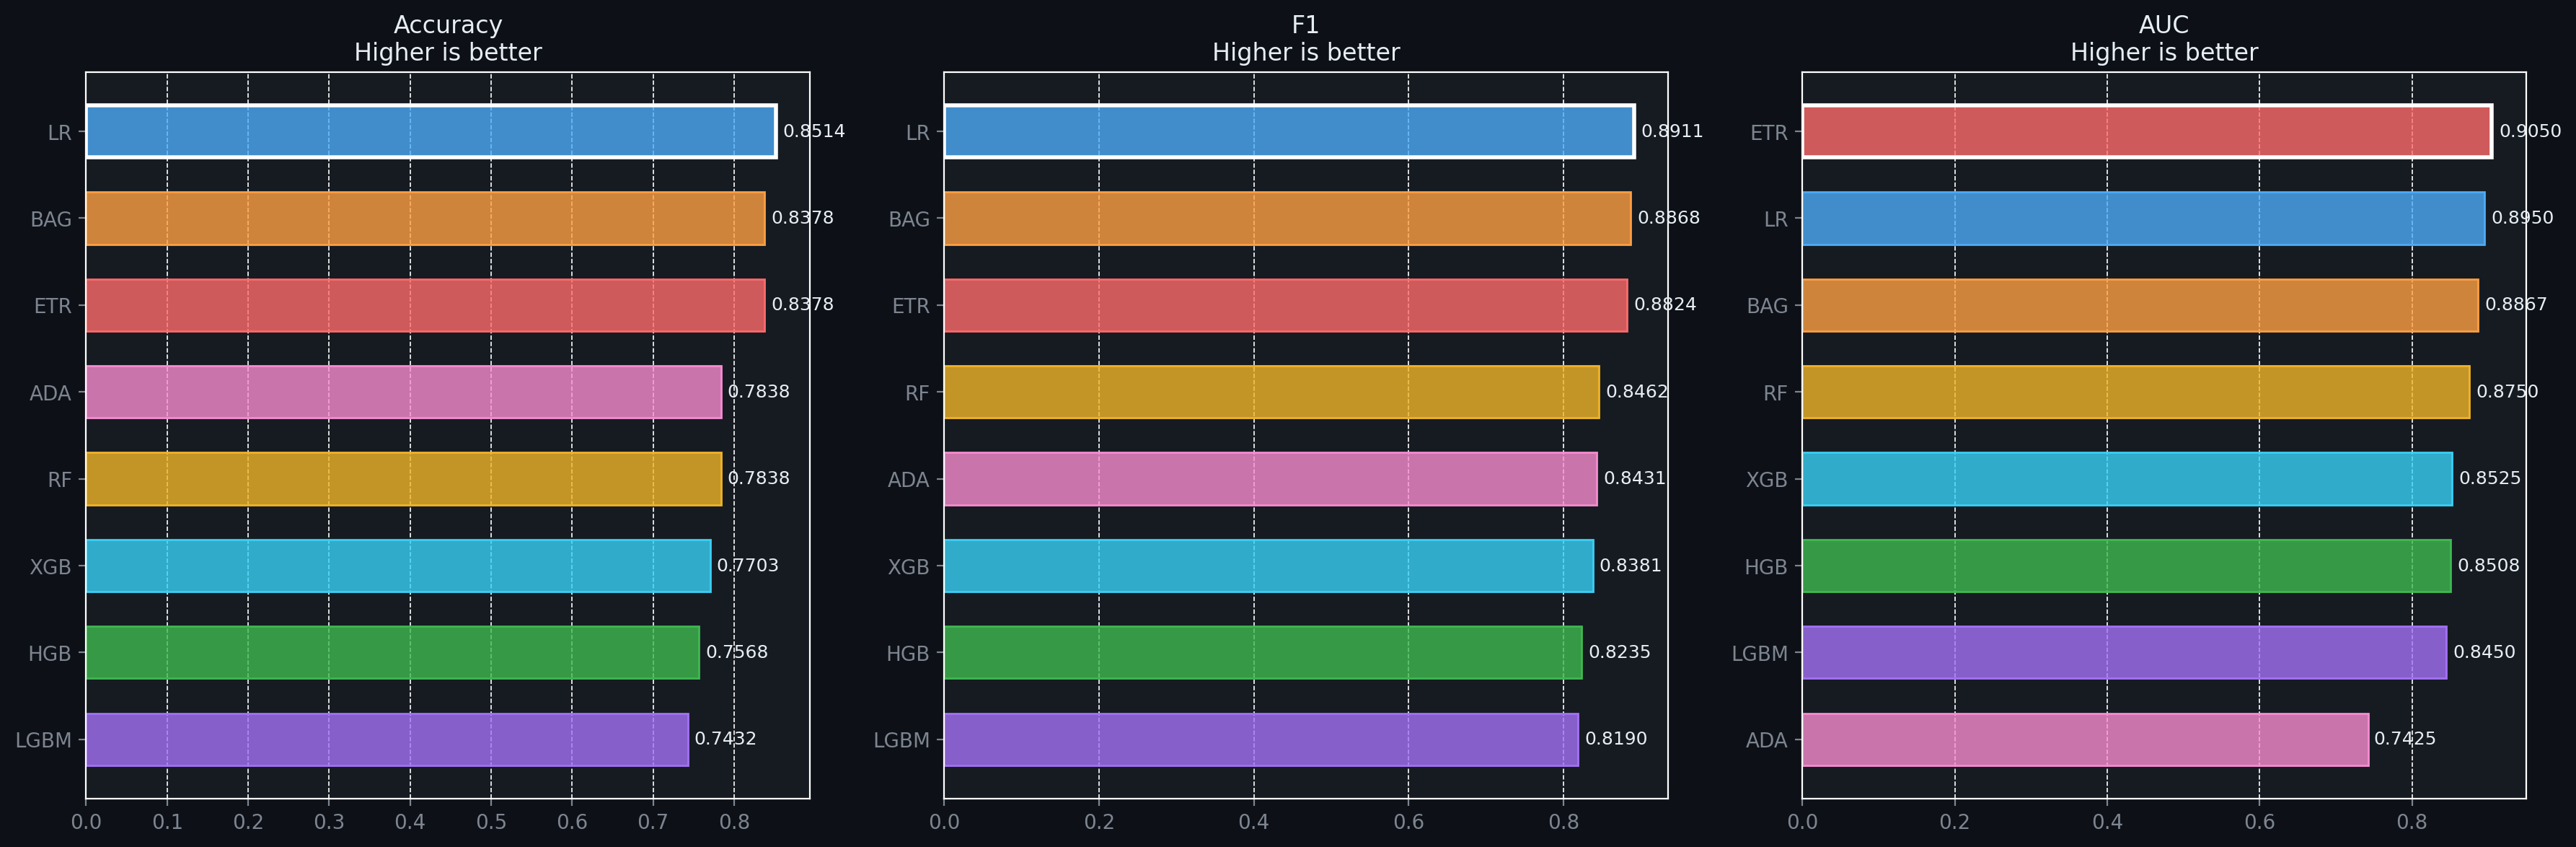

In [165]:
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')

metrics = [
    ('Accuracy', 'Higher is better', True),
    ('F1', 'Higher is better', True),
    ('AUC', 'Higher is better', True)
]

for ax, (metric, subtitle, higher_better) in zip(axes, metrics):
    ax.set_facecolor(SURF)

    df_sorted = results_df.sort_values(metric, ascending=not higher_better)
    names  = [SHORT_NAMES[m] for m in df_sorted['model']]
    vals   = df_sorted[metric].values
    colors = [MODEL_COLORS[m] for m in df_sorted['model']]

    bars = ax.barh(names, vals,
                    color=[c+'cc' for c in colors],
                    edgecolor=colors, linewidth=1, height=0.6)

    best_idx = 0
    bars[best_idx].set_edgecolor('white')
    bars[best_idx].set_linewidth(2)

    for bar, val in zip(bars, vals):
        ax.text(val * 1.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}',
                va='center', color=TEXT, fontsize=9)

    ax.set_title(f'{metric}\n{subtitle}', color=TEXT)
    ax.tick_params(colors=MUTED)
    ax.grid(axis='x', linestyle='--', lw=0.6)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

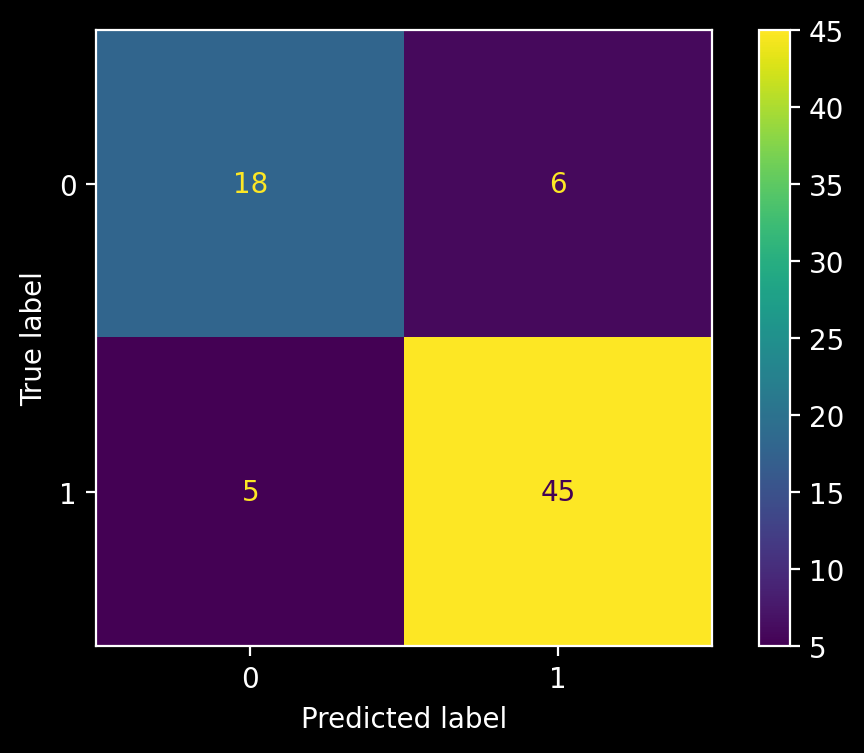

In [172]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics

ConfusionMatrixDisplay.from_estimator(SEARCHES['LogisticRegression'], X_test, y_test)
plt.show()

In [173]:
print(metrics.classification_report(y_test,  SEARCHES['LogisticRegression'].predict(X_test)))

              precision    recall  f1-score   support

           0       0.78      0.75      0.77        24
           1       0.88      0.90      0.89        50

    accuracy                           0.85        74
   macro avg       0.83      0.82      0.83        74
weighted avg       0.85      0.85      0.85        74



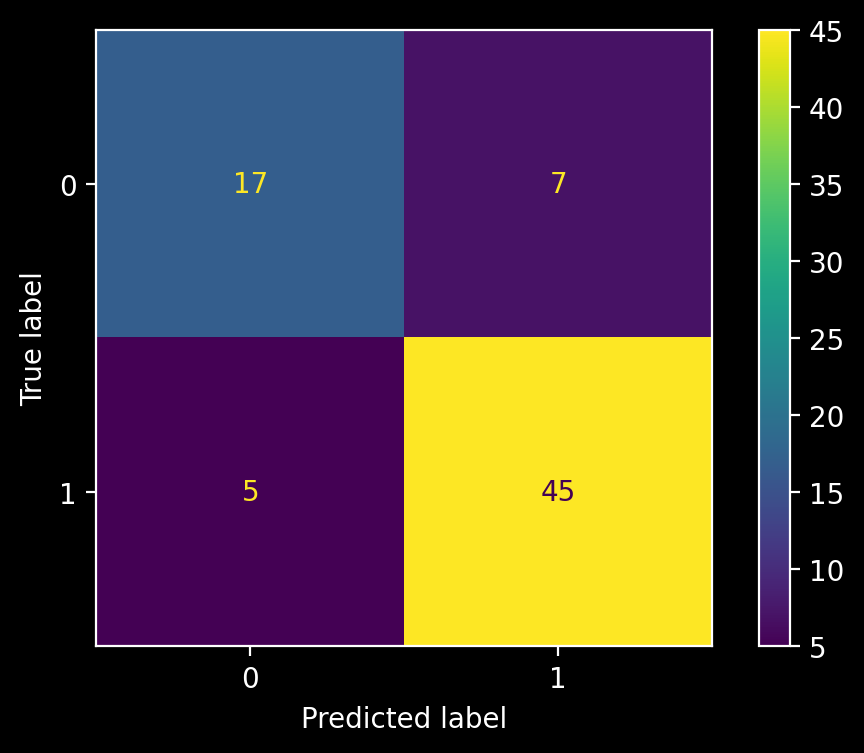

In [174]:
ConfusionMatrixDisplay.from_estimator(SEARCHES['ExtraTreesClassifier'], X_test, y_test)
plt.show()

In [175]:
print(metrics.classification_report(y_test,  SEARCHES['ExtraTreesClassifier'].predict(X_test)))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        24
           1       0.87      0.90      0.88        50

    accuracy                           0.84        74
   macro avg       0.82      0.80      0.81        74
weighted avg       0.84      0.84      0.84        74



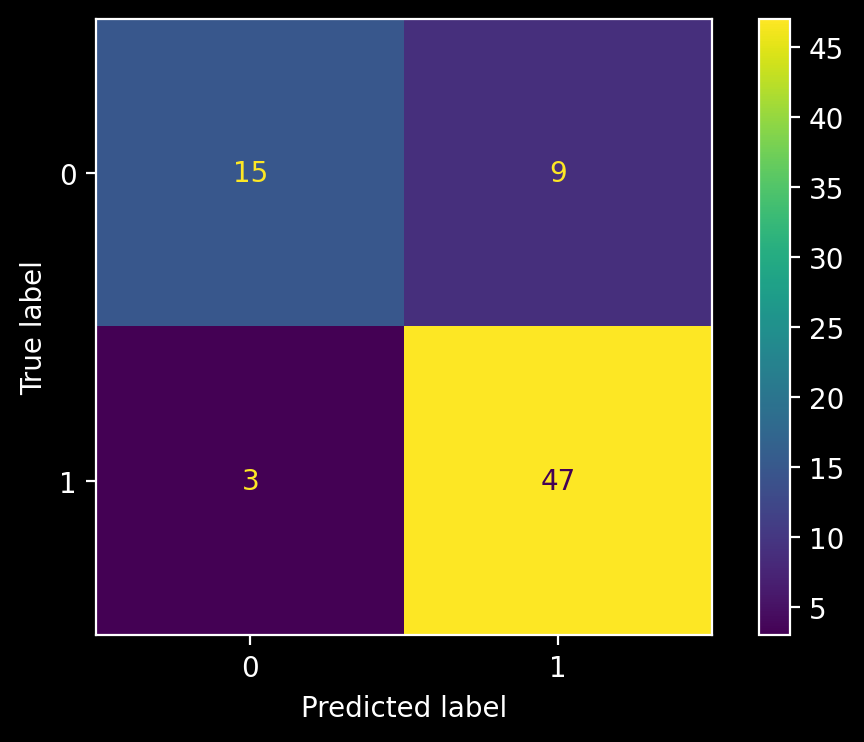

In [181]:
ConfusionMatrixDisplay.from_estimator(SEARCHES['BaggingClassifier'], X_test, y_test)
plt.show()

In [182]:
print(metrics.classification_report(y_test,  SEARCHES['BaggingClassifier'].predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.62      0.71        24
           1       0.84      0.94      0.89        50

    accuracy                           0.84        74
   macro avg       0.84      0.78      0.80        74
weighted avg       0.84      0.84      0.83        74



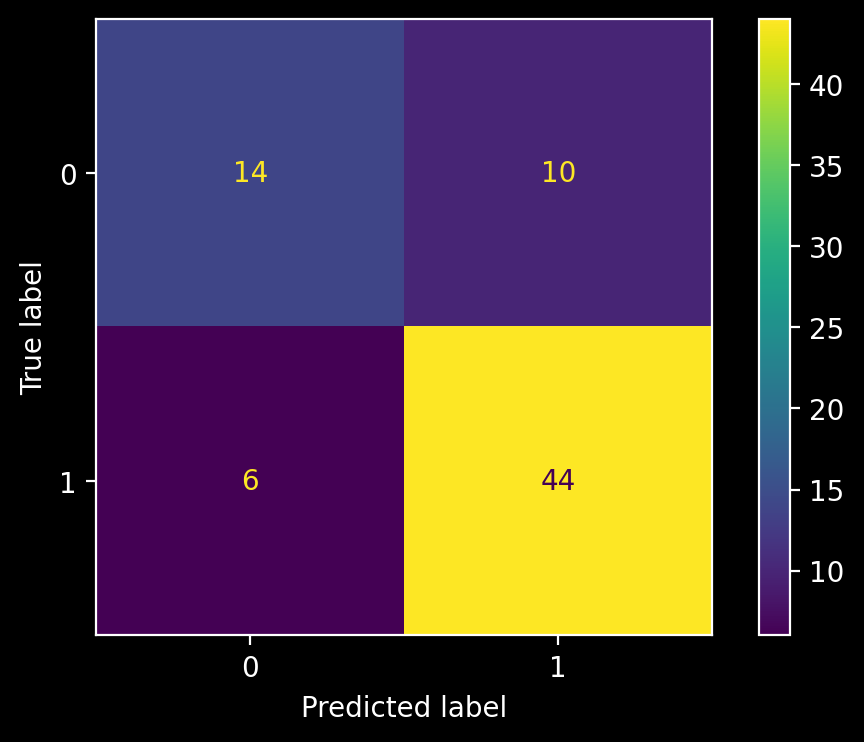

In [179]:
ConfusionMatrixDisplay.from_estimator(SEARCHES['RandomForestClassifier'], X_test, y_test)
plt.show()

In [180]:
print(metrics.classification_report(y_test,  SEARCHES['RandomForestClassifier'].predict(X_test)))

              precision    recall  f1-score   support

           0       0.70      0.58      0.64        24
           1       0.81      0.88      0.85        50

    accuracy                           0.78        74
   macro avg       0.76      0.73      0.74        74
weighted avg       0.78      0.78      0.78        74



[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4


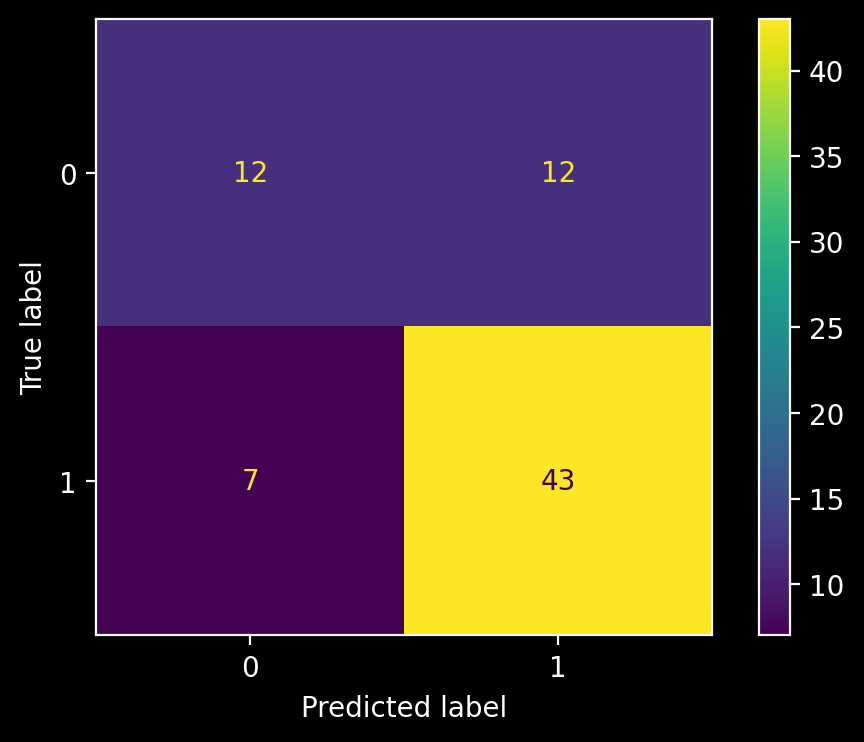

In [177]:
ConfusionMatrixDisplay.from_estimator(SEARCHES['LGBMClassifier'], X_test, y_test)
plt.show()

In [178]:
print(metrics.classification_report(y_test,  SEARCHES['LGBMClassifier'].predict(X_test)))

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
              precision    recall  f1-score   support

           0       0.63      0.50      0.56        24
           1       0.78      0.86      0.82        50

    accuracy                           0.74        74
   macro avg       0.71      0.68      0.69        74
weighted avg       0.73      0.74      0.73        74



# A Quick Look at Permutation Importance

In [185]:
from sklearn.inspection import permutation_importance

In [186]:
perm_importance = permutation_importance(
    SEARCHES['LogisticRegression'].best_estimator_, X_test, y_test, n_repeats=30, random_state=0, scoring='balanced_accuracy'
)

In [188]:
perm_importance_df = pd.DataFrame(
    dict(
        feature=X_test.columns,
        pi_mean=perm_importance['importances_mean'],
        pi_std=perm_importance['importances_std']
    )
)

perm_importance_df

,feature,pi_mean,pi_std
0,pressure,0.008444,0.015004
1,temparature,0.000000,0.000000
2,dewpoint,0.009528,0.016407
3,humidity,0.039083,0.028208
4,cloud,0.244417,0.049374
5,sunshine,0.043167,0.021003
6,winddirection,0.005528,0.015136
7,windspeed,0.017028,0.017509


In [189]:
# Sorting by permutation importance mean
perm_importance_df_sorted = perm_importance_df.sort_values(by='pi_mean', ascending=True)

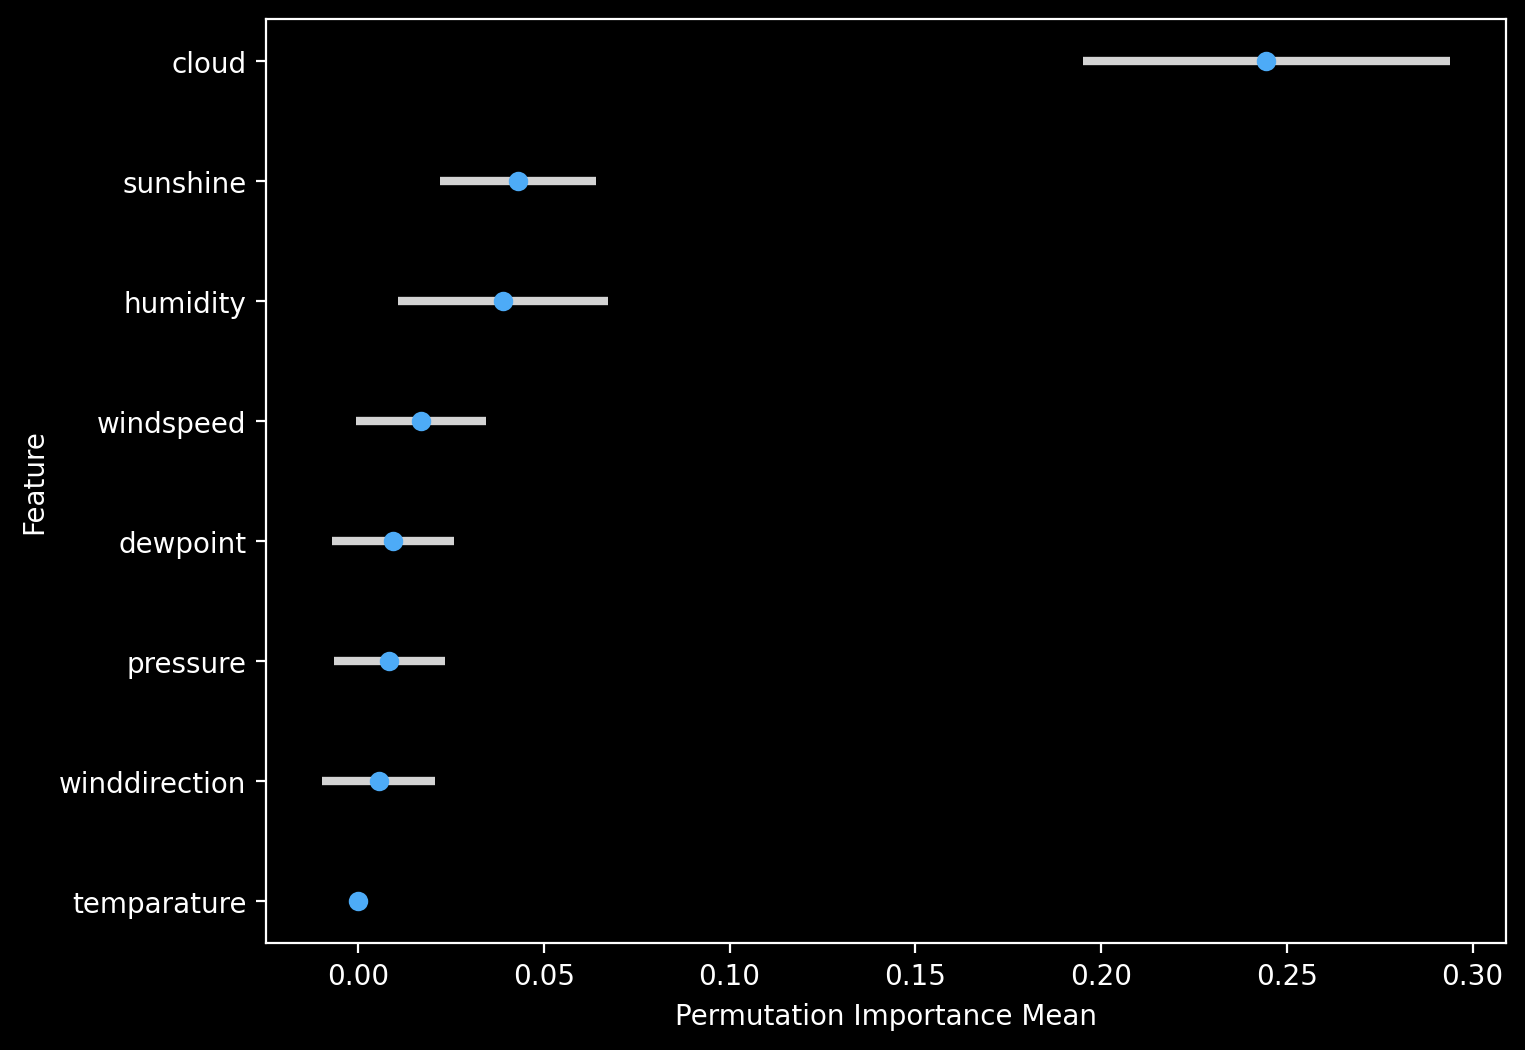

In [191]:
# Visualisation Option 1: Error Bars
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(
    perm_importance_df_sorted['pi_mean'],
    perm_importance_df_sorted['feature'],
    xerr=perm_importance_df_sorted['pi_std'],
    fmt='o', color=BLUE,
    ecolor='lightgray', elinewidth=3, capsize=0
)

ax.set_ylabel('Feature')
ax.set_xlabel('Permutation Importance Mean');

# SHAP

In [196]:
# Not ideal, perhaps, but currently it makes life easier if one pre-processes
# the data used for SHAP computations
pp = SEARCHES['LogisticRegression'].best_estimator_['pp']

X_train_pp = PP.transform(X_train)
X_train_pp = pd.DataFrame(
    X_train_pp,
    columns=pp.get_feature_names_out()
)

column_names = X_train_pp.columns

X_test_pp  = PP.transform(X_test)
X_test_pp = pd.DataFrame(
    X_test_pp,
    columns=pp.get_feature_names_out()
)

In [202]:
explainer = shap.Explainer(SEARCHES['LogisticRegression'].best_estimator_['model'], X_train_pp)

explainer

In [203]:
explanations = explainer(X_test_pp, check_additivity=False)

In [204]:
explanations.shape

(74, 8)

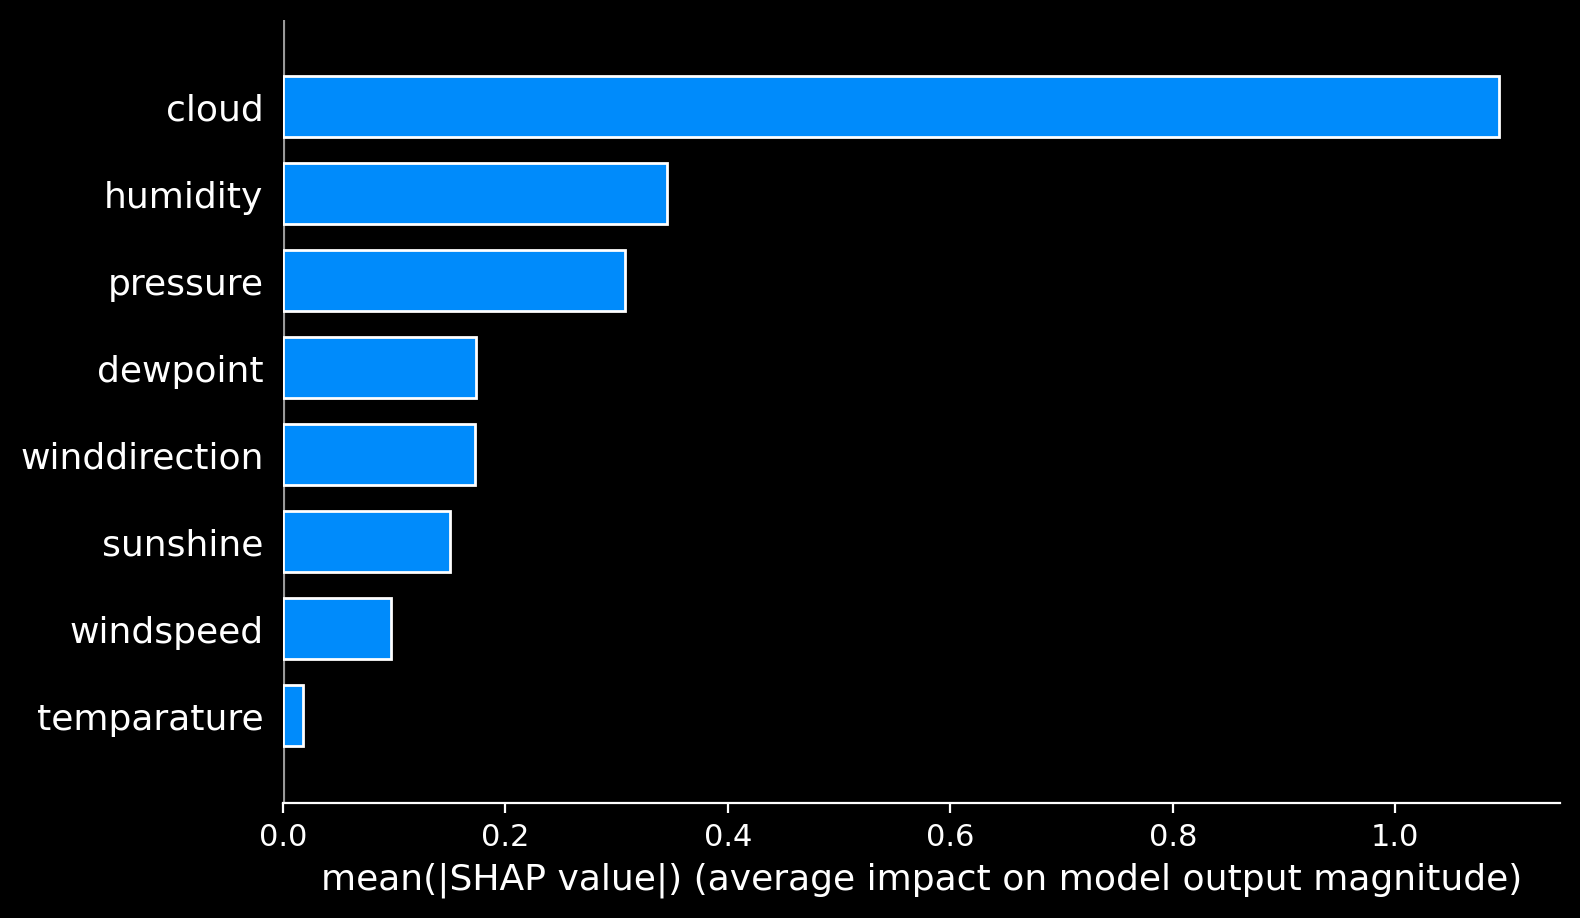

In [213]:
plt.subplots(figsize=(20, 9))

shap.summary_plot(explanations, X, plot_type='bar', show=False)
ax = plt.gca()
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
plt.show()

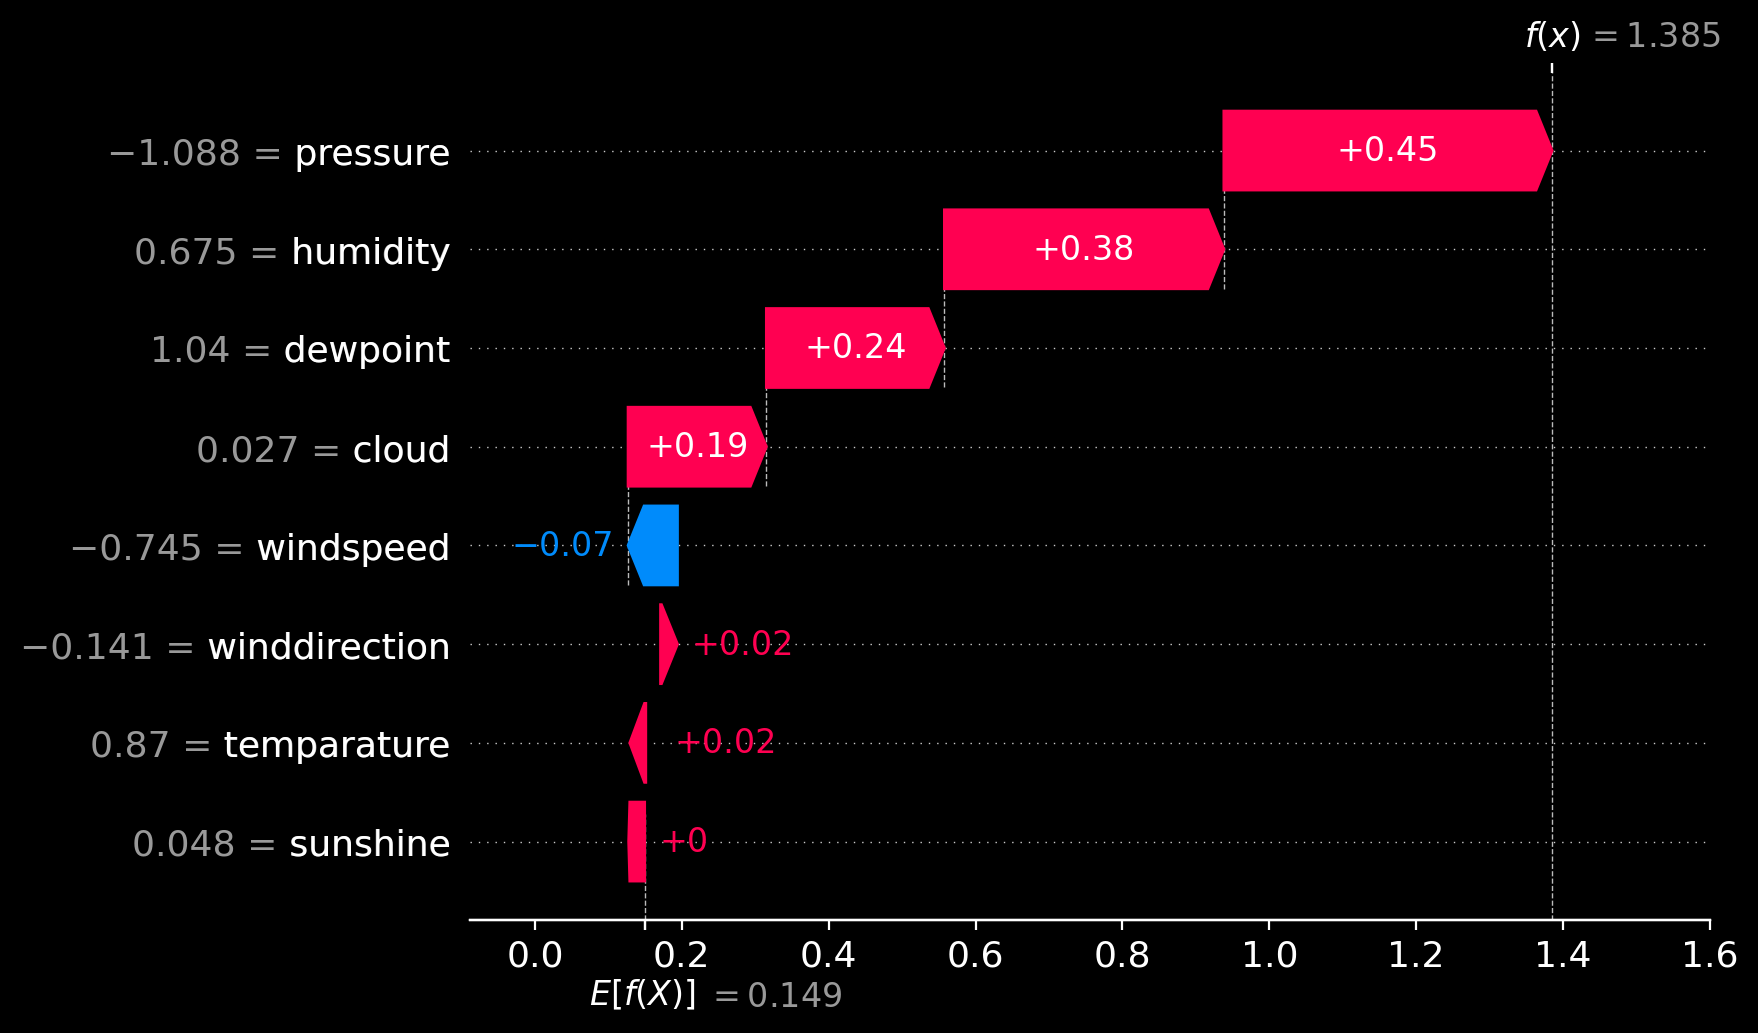

In [205]:
shap.plots.waterfall(explanations[0])

In [206]:
shap.initjs()
shap.plots.force(explanations[0])

## Global SHAP Values

In [208]:
shap_values = explainer.shap_values(X_test_pp)

In [209]:
shap_values.shape

(74, 8)

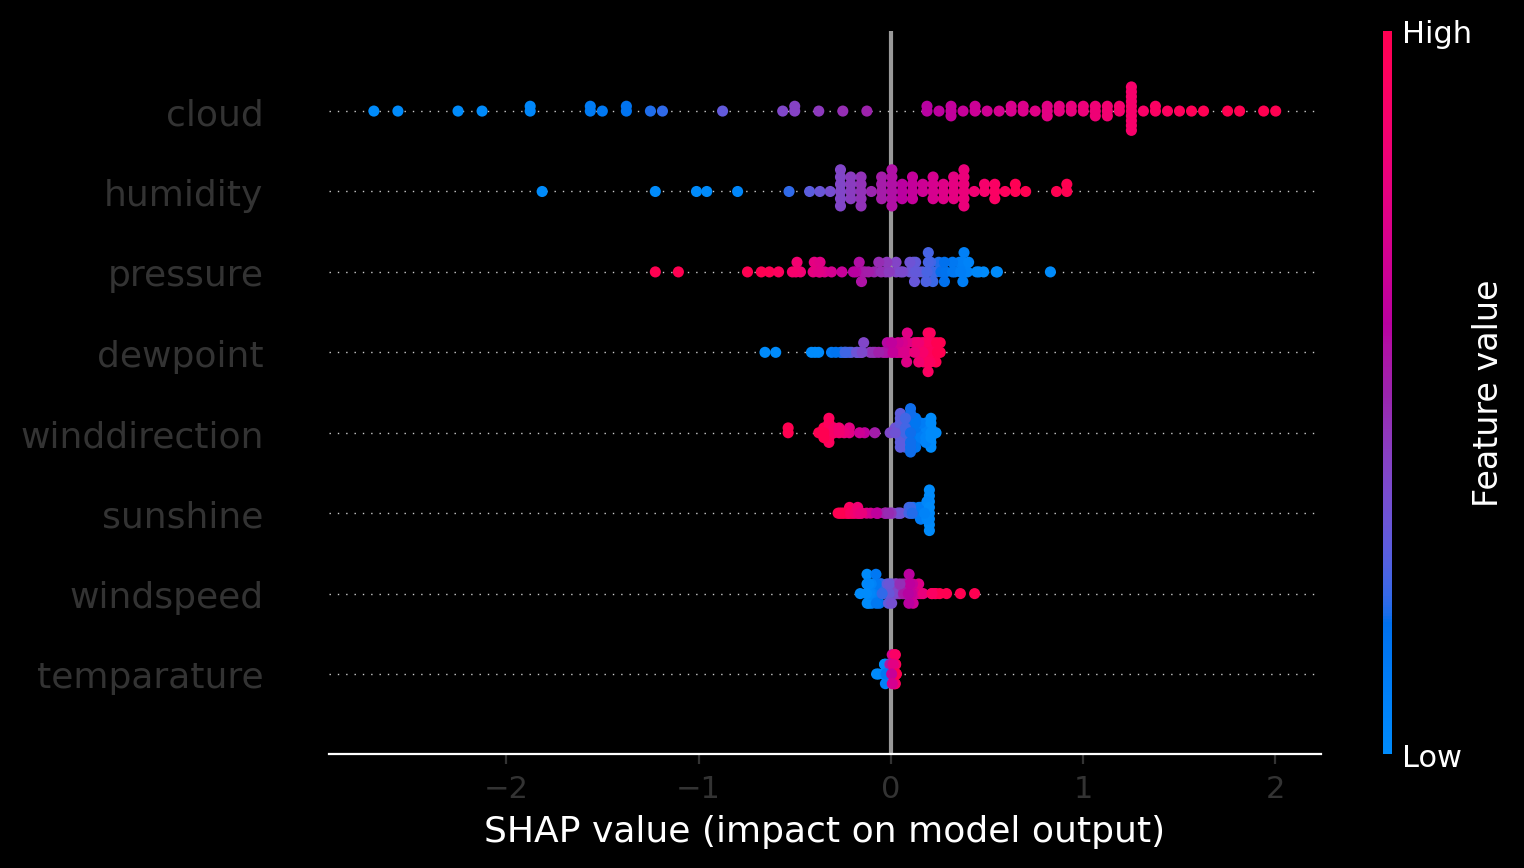

In [214]:
shap.plots.beeswarm(explanations)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
plt.show()

In [215]:
shap.initjs()
shap.plots.force(explanations)

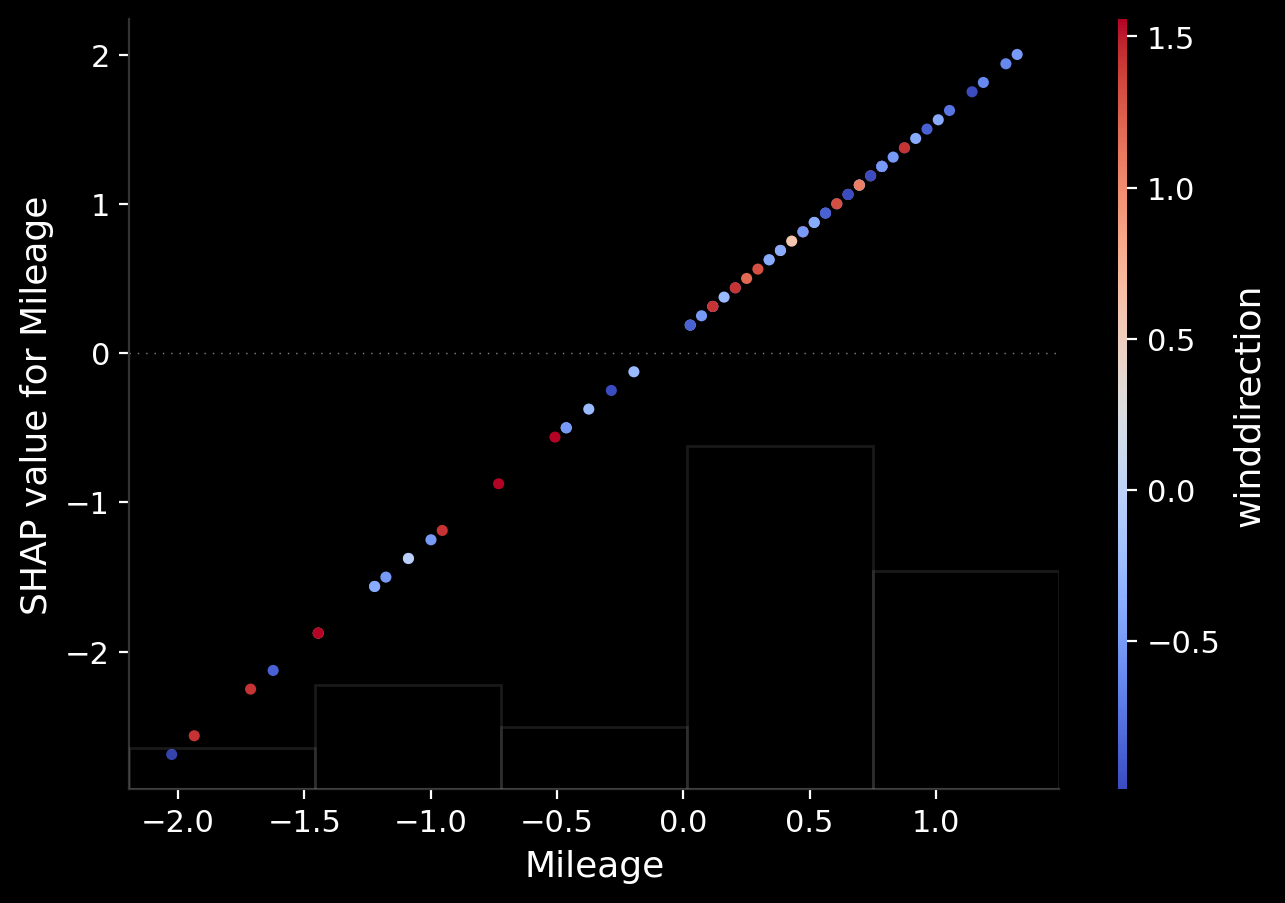

In [216]:

shap.plots.scatter(
    explanations[:, "cloud"],
    color=explanations,
    cmap="coolwarm",
    show=False
)

ax = plt.gca()
ax.set_facecolor('black')

ax.set_xlabel("Cloud", color="white")
ax.set_ylabel("SHAP value for Cloud", color="white")

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.show()

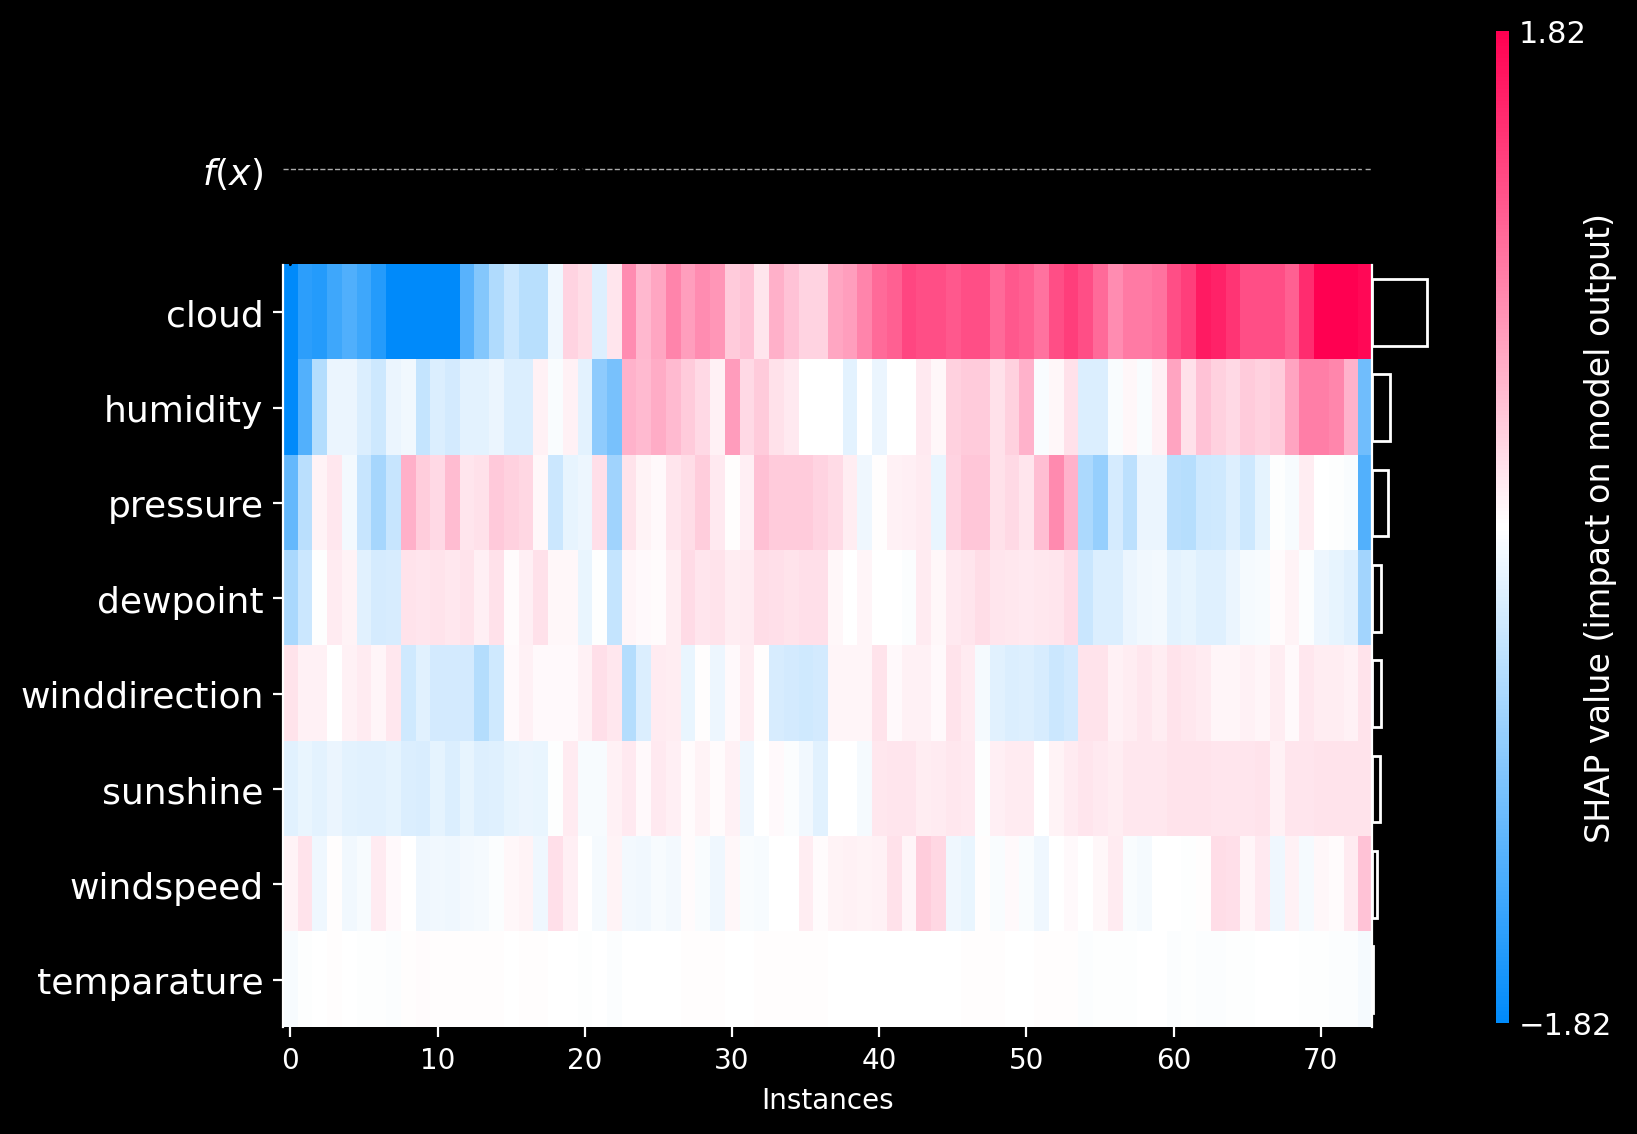

<Axes: xlabel='Instances'>

In [217]:
shap.plots.heatmap(explanations)